# Reproject & Overlay â€” Landsat 30 m over VIIRS 375 m

**Full Alaska domain:** VIIRS is reprojected to a 375 m UTM grid covering the
entire Alaska extent (lat 54â€“72, lon âˆ’171 to âˆ’129).  Landsat scenes are
reprojected at 30 m within their **own per-scene footprints** (full Alaska at
30 m would be ~20 GB/band), then mosaicked where they overlap.

| Sensor | Native res | Target grid | Extent |
|--------|-----------|-------------|--------|
| VIIRS I-band (swath) | 375 m | 375 m UTM | Full Alaska domain |
| Landsat 8/9 L1 (GeoTIFF) | 30 m | 30 m UTM | Per-scene footprint |

Alaska domain: **lat (54, 72) â€” lon (âˆ’171, âˆ’129)**

In [18]:
# CELL 0  IMPORTS & PARAMETERS
import os, glob, re, warnings, time
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import h5py
import matplotlib.pyplot as plt
import rasterio
from rasterio.transform import from_bounds
from rasterio.warp import reproject, Resampling
from pyproj import CRS, Transformer

try:
    from tqdm.auto import tqdm
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tqdm"])
    from tqdm.auto import tqdm

try:
    from pyresample import geometry, image
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyresample"])
    from pyresample import geometry, image

%matplotlib inline

#  paths 
_cwd = os.getcwd()
ROOT = os.path.normpath(os.path.join(_cwd, "..")) if os.path.basename(_cwd) == "notebooks" else _cwd

VIIRS_DIR   = os.path.join(ROOT, "data", "viirs")
LANDSAT_DIR = os.path.join(ROOT, "data", "landsat")
OUTPUT_DIR  = os.path.join(ROOT, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

#  Alaska domain  used as the VIIRS processing extent 
ALASKA_BBOX = (54.0, 72.0, -171.0, -129.0)  # (lat_min, lat_max, lon_min, lon_max)

# Landsat is reprojected per-scene (own footprint)  full Alaska at 30 m
# would be ~20 GB/band, so we avoid creating a single domain-wide 30 m grid.

VIIRS_RES   = 375.0   # metres
LANDSAT_RES =  30.0

print(f"Alaska domain  : {ALASKA_BBOX}")
print(f"VIIRS dir      : {VIIRS_DIR}")
print(f"Landsat dir    : {LANDSAT_DIR}")

Alaska domain  : (54.0, 72.0, -171.0, -129.0)
VIIRS dir      : d:\Reprojection\data\viirs
Landsat dir    : d:\Reprojection\data\landsat


In [19]:
# CELL 1 - HELPER FUNCTIONS

def choose_utm_crs(lon0, lat0):
    zone = int((lon0 + 180) / 6) + 1
    return CRS.from_epsg(32600 + zone if lat0 >= 0 else 32700 + zone)


#  VIIRS readers 
def read_viirs_geo(h5_path):
    """Read geolocation: lat, lon, solar/satellite angles.
    Works with GITCO (VIIRS-IMG-GEO-TC_All) and GIMGO (VIIRS-IMG-GEO_All)."""
    # Try terrain-corrected first (GITCO), then non-TC (GIMGO)
    geo_grps = ["All_Data/VIIRS-IMG-GEO-TC_All", "All_Data/VIIRS-IMG-GEO_All"]
    fields = [
        "Latitude", "Longitude",
        "SatelliteAzimuthAngle", "SatelliteZenithAngle",
        "SolarAzimuthAngle", "SolarZenithAngle",
    ]
    out = {}
    with h5py.File(h5_path, "r") as h5:
        grp = None
        for g in geo_grps:
            if g in h5:
                grp = g
                break
        if grp is None:
            return out
        for f in fields:
            p = f"{grp}/{f}"
            if p in h5:
                out[f] = np.array(h5[p], dtype=np.float32)
    return out


def read_viirs_sdr(h5_path, band):
    """Read VIIRS I-band SDR. Works with GIMGO-SVI combined or standalone files."""
    sdr_grp = f"All_Data/VIIRS-I{band}-SDR_All"
    if band <= 3:
        var_names = ["Reflectance", "ReflectanceFactors"]
    else:
        var_names = ["BrightnessTemperature", "BrightnessTemperatureFactors"]
    out = {}
    with h5py.File(h5_path, "r") as h5:
        if sdr_grp not in h5 and "All_Data" in h5:
            hits = [k for k in h5["All_Data"] if f"VIIRS-I{band}-SDR" in k]
            if hits:
                sdr_grp = f"All_Data/{hits[0]}"
            else:
                return out
        for vn in var_names:
            dp = f"{sdr_grp}/{vn}"
            if dp in h5:
                out[vn] = np.array(h5[dp])
    return out


def apply_viirs_scaling(raw, factors=None):
    out = raw.astype(np.float32, copy=True)
    out[(out == 63999) | (out == 65533) | (out > 65529)] = np.nan
    if factors is not None and len(factors) >= 1:
        out *= float(factors[0])
        if len(factors) >= 2:
            out += float(factors[1])
    return out


def has_viirs_sdr(h5_path):
    """Return list of I-band numbers whose SDR groups exist."""
    bands = []
    with h5py.File(h5_path, "r") as h5:
        if "All_Data" not in h5:
            return bands
        for k in h5["All_Data"]:
            for b in range(1, 6):
                if f"VIIRS-I{b}-SDR" in k:
                    bands.append(b)
    return sorted(set(bands))


def has_viirs_geo(h5_path):
    """Check if file contains geolocation data."""
    with h5py.File(h5_path, "r") as h5:
        for grp in ["All_Data/VIIRS-IMG-GEO-TC_All", "All_Data/VIIRS-IMG-GEO_All"]:
            if grp in h5 and f"{grp}/Latitude" in h5:
                return True
    return False


def viirs_orbit_key(filename):
    """Extract date+time key from VIIRS filename for matching GITCO<->GIMGO-SVI."""
    m = re.search(r"_d(\d{8})_t(\d{7})", filename)
    return f"{m.group(1)}_{m.group(2)}" if m else None


# ---- Landsat readers -----------------------------------------------------
def discover_landsat_scenes(landsat_dir):
    """Group Landsat TIFs by scene ID."""
    scenes = {}
    for p in sorted(glob.glob(os.path.join(landsat_dir, "*.TIF"))):
        fn = os.path.basename(p)
        parts = fn.replace(".TIF", "").split("_")
        if len(parts) < 5:
            continue
        sid  = "_".join(parts[:4])
        band = parts[-1]
        if sid not in scenes:
            scenes[sid] = {
                "date": parts[3],
                "satellite": "L8" if fn.startswith("LC08") else "L9",
                "bands": {}, "crs": None, "bounds": None,
            }
        scenes[sid]["bands"][band] = p
    for sid, info in scenes.items():
        fp = next(iter(info["bands"].values()))
        with rasterio.open(fp) as src:
            info["crs"]    = src.crs
            info["bounds"] = src.bounds
    return scenes


def scene_covers_bbox(info, bbox):
    """Does scene footprint overlap lat/lon bbox?"""
    lat_min, lat_max, lon_min, lon_max = bbox
    b = info["bounds"]
    to_ll = Transformer.from_crs(info["crs"], "EPSG:4326", always_xy=True)
    cs = [to_ll.transform(b.left, b.bottom), to_ll.transform(b.right, b.bottom),
          to_ll.transform(b.right, b.top),   to_ll.transform(b.left, b.top)]
    slon = [c[0] for c in cs]; slat = [c[1] for c in cs]
    return not (max(slon) < lon_min or min(slon) > lon_max
               or max(slat) < lat_min or min(slat) > lat_max)


# ---- Reprojection --------------------------------------------------------
def viirs_swath_to_grid(lat, lon, data, dst_crs, res_m, bbox):
    """Reproject VIIRS swath -> UTM grid via pyresample nearest-neighbour."""
    lat_min, lat_max, lon_min, lon_max = bbox
    to_utm = Transformer.from_crs("EPSG:4326", dst_crs, always_xy=True)

    buf = 0.5
    ok = (np.isfinite(lat) & np.isfinite(lon) & np.isfinite(data)
          & (lat >= lat_min - buf) & (lat <= lat_max + buf)
          & (lon >= lon_min - buf) & (lon <= lon_max + buf))
    lats_m = np.ma.masked_array(lat, ~ok)
    lons_m = np.ma.masked_array(lon, ~ok)
    data_m = np.ma.masked_array(data.astype(np.float32), ~ok)

    cs = [to_utm.transform(x, y) for x, y in
          [(lon_min, lat_min), (lon_max, lat_min),
           (lon_max, lat_max), (lon_min, lat_max)]]
    x0, x1 = min(c[0] for c in cs), max(c[0] for c in cs)
    y0, y1 = min(c[1] for c in cs), max(c[1] for c in cs)
    w = max(1, int(np.ceil((x1 - x0) / res_m)))
    h = max(1, int(np.ceil((y1 - y0) / res_m)))

    zone = int((0.5 * (lon_min + lon_max) + 180) / 6) + 1
    proj_dict = {"proj": "utm", "zone": zone, "ellps": "WGS84", "units": "m"}
    area_def  = geometry.AreaDefinition("v", "v", "v", proj_dict, w, h, (x0, y0, x1, y1))
    swath_def = geometry.SwathDefinition(lons=lons_m, lats=lats_m)

    con = image.ImageContainerNearest(data_m, swath_def,
                                      radius_of_influence=7000, epsilon=0.375, nprocs=1)
    arr = con.resample(area_def).image_data
    result = np.ma.filled(arr, np.nan).astype(np.float32) if np.ma.is_masked(arr) else np.asarray(arr, np.float32)
    return result, from_bounds(x0, y0, x1, y1, w, h)


def reproject_landsat_band(tif_path, dst_crs, res_m, target_extent=None):
    """Reproject one Landsat band TIF -> target UTM grid."""
    with rasterio.open(tif_path) as src:
        if target_extent:
            x0, y0, x1, y1 = target_extent
        else:
            t = Transformer.from_crs(src.crs, dst_crs, always_xy=True)
            cs = [t.transform(src.bounds.left, src.bounds.bottom),
                  t.transform(src.bounds.right, src.bounds.bottom),
                  t.transform(src.bounds.right, src.bounds.top),
                  t.transform(src.bounds.left, src.bounds.top)]
            x0 = min(c[0] for c in cs); x1 = max(c[0] for c in cs)
            y0 = min(c[1] for c in cs); y1 = max(c[1] for c in cs)
        w = max(1, int(np.ceil((x1 - x0) / res_m)))
        h = max(1, int(np.ceil((y1 - y0) / res_m)))
        dst_tf = from_bounds(x0, y0, x1, y1, w, h)
        raw = src.read(1).astype(np.float32)
        raw[raw == 0] = np.nan
        dst = np.full((h, w), np.nan, np.float32)
        reproject(raw, dst, src_transform=src.transform, src_crs=src.crs,
                  src_nodata=np.nan, dst_transform=dst_tf, dst_crs=dst_crs,
                  dst_nodata=np.nan, resampling=Resampling.bilinear)
    return dst, dst_tf


def save_geotiff(arr, tf, crs, path, nodata=-9999.0):
    filled = np.where(np.isfinite(arr), arr, nodata).astype(np.float32)
    h, w = arr.shape
    with rasterio.open(path, "w", driver="GTiff", height=h, width=w, count=1,
                       dtype=np.float32, crs=crs, transform=tf, nodata=nodata) as dst:
        dst.write(filled, 1)
    print(f"  -> {os.path.basename(path)}  ({w}x{h})")


def save_rgb_geotiff(r, g, b, tf, crs, path, nodata=-9999.0):
    h, w = r.shape
    with rasterio.open(path, "w", driver="GTiff", height=h, width=w, count=3,
                       dtype=np.float32, crs=crs, transform=tf, nodata=nodata) as dst:
        for i, band in enumerate([r, g, b], 1):
            dst.write(np.where(np.isfinite(band), band, nodata).astype(np.float32), i)
    print(f"  -> {os.path.basename(path)}  (3-band RGB, {w}x{h})")


print("Helpers loaded.")

Helpers loaded.


In [20]:
# CELL 2 - DATA INVENTORY

# -- VIIRS files - pair GITCO (terrain-corrected geo) with GIMGO-SVI (bands) --
viirs_files = sorted(glob.glob(os.path.join(VIIRS_DIR, "*.h5")))
print(f"VIIRS HDF5 files found: {len(viirs_files)}\n")

# Classify each file and group by orbit key (date_time)
gitco_by_orbit = {}   # orbit_key -> path
gimgo_by_orbit = {}   # orbit_key -> path

for fp in tqdm(viirs_files, desc="Scanning VIIRS files"):
    fn = os.path.basename(fp)
    okey = viirs_orbit_key(fn)
    if okey is None:
        print(f"  SKIP (no date/time): {fn}")
        continue

    has_geo = has_viirs_geo(fp)
    sdr_bands = has_viirs_sdr(fp)
    ftype = "GITCO" if fn.startswith("GITCO") else "GIMGO-SVI"

    print(f"  [{ftype}] {fn[:70]}")
    print(f"    orbit={okey}  geo={'YES' if has_geo else 'no'}  SDR bands: {sdr_bands if sdr_bands else 'NONE'}")

    if fn.startswith("GITCO"):
        gitco_by_orbit[okey] = fp
    else:
        gimgo_by_orbit[okey] = fp

# Pair orbits: prefer GITCO geo (terrain-corrected) + GIMGO-SVI bands
viirs_orbits = {}
all_orbit_keys = sorted(set(list(gitco_by_orbit.keys()) + list(gimgo_by_orbit.keys())))

print(f"\n{'='*60}")
print(f"VIIRS Orbits: {len(all_orbit_keys)}")
print(f"{'='*60}")

for okey in all_orbit_keys:
    gitco_path = gitco_by_orbit.get(okey)
    gimgo_path = gimgo_by_orbit.get(okey)

    # Determine geo source (prefer GITCO terrain-corrected)
    geo_path = gitco_path if gitco_path else gimgo_path
    sdr_path = gimgo_path  # bands always come from GIMGO-SVI

    sdr_bands = has_viirs_sdr(sdr_path) if sdr_path else []

    # Check lat coverage
    geo = read_viirs_geo(geo_path)
    lat = geo.get("Latitude")
    if lat is not None:
        ok = (lat > -90) & (lat < 90)
        lat_range = (float(lat[ok].min()), float(lat[ok].max()))
        covers_ak = lat_range[1] >= ALASKA_BBOX[0] and lat_range[0] <= ALASKA_BBOX[1]
    else:
        lat_range = (None, None)
        covers_ak = False

    viirs_orbits[okey] = {
        "orbit_key": okey,
        "gitco_path": gitco_path,
        "gimgo_path": gimgo_path,
        "geo_path": geo_path,
        "sdr_path": sdr_path,
        "sdr_bands": sdr_bands,
        "lat_range": lat_range,
        "covers_alaska": covers_ak,
    }

    tag = " - covers Alaska" if covers_ak else ""
    geo_src = "GITCO (terrain-corrected)" if gitco_path else "GIMGO (non-TC)"
    print(f"\n  Orbit {okey}:")
    print(f"    Geo source : {geo_src}")
    print(f"    SDR bands  : I{sdr_bands}" if sdr_bands else "    SDR bands  : NONE")
    print(f"    Lat range  : [{lat_range[0]:.1f}, {lat_range[1]:.1f}]{tag}")

# Select best orbit covering Alaska (with most bands)
ak_orbits = {k: v for k, v in viirs_orbits.items() if v["covers_alaska"]}
if ak_orbits:
    viirs_pick_orbit = max(ak_orbits.values(), key=lambda v: (len(v["sdr_bands"]), v["lat_range"][1]))
else:
    viirs_pick_orbit = next(iter(viirs_orbits.values()))

print(f"\n{'='*60}")
print(f"Selected orbit: {viirs_pick_orbit['orbit_key']}")
print(f"  Geo file : {os.path.basename(viirs_pick_orbit['geo_path'])[:70]}")
if viirs_pick_orbit['sdr_path']:
    print(f"  SDR file : {os.path.basename(viirs_pick_orbit['sdr_path'])[:70]}")
    print(f"  Bands    : I{viirs_pick_orbit['sdr_bands']}")
else:
    print(f"  SDR file : NONE - angles only")

# -- Landsat scenes ---------------------------------------------------------
all_scenes = discover_landsat_scenes(LANDSAT_DIR)
print(f"\nLandsat scenes: {len(all_scenes)}")

aoi_scenes = {sid: s for sid, s in all_scenes.items() if scene_covers_bbox(s, ALASKA_BBOX)}
print(f"Scenes overlapping Alaska domain: {len(aoi_scenes)}")
for sid in sorted(aoi_scenes):
    s = aoi_scenes[sid]
    has_rgb = all(b in s["bands"] for b in ["B2", "B3", "B4"])
    print(f"  {sid}  {s['satellite']} {s['date']}  bands={sorted(s['bands'].keys())}  "
          f"RGB={'YES' if has_rgb else 'no'}  CRS={s['crs']}")

VIIRS HDF5 files found: 4



Scanning VIIRS files:   0%|          | 0/4 [00:00<?, ?it/s]

  [GIMGO-SVI] GIMGO-SVI01-SVI02-SVI03-SVI04-SVI05_npp_d20240112_t2356065_e0001469_b6
    orbit=20240112_2356065  geo=YES  SDR bands: [1, 2, 3, 4, 5]
  [GIMGO-SVI] GIMGO-SVI01-SVI03-SVI04_npp_d20240113_t0001481_e0007285_b63271_c202603
    orbit=20240113_0001481  geo=YES  SDR bands: [1, 3, 4]
  [GITCO] GITCO_npp_d20240112_t2356065_e0001469_b63271_c20240113015429293000_oea
    orbit=20240112_2356065  geo=YES  SDR bands: NONE
  [GITCO] GITCO_npp_d20240113_t0001481_e0007285_b63271_c20240113015555720000_oea
    orbit=20240113_0001481  geo=YES  SDR bands: NONE

VIIRS Orbits: 2

  Orbit 20240112_2356065:
    Geo source : GITCO (terrain-corrected)
    SDR bands  : I[1, 2, 3, 4, 5]
    Lat range  : [32.5, 57.4] - covers Alaska

  Orbit 20240113_0001481:
    Geo source : GITCO (terrain-corrected)
    SDR bands  : I[1, 3, 4]
    Lat range  : [50.2, 77.3] - covers Alaska

Selected orbit: 20240112_2356065
  Geo file : GITCO_npp_d20240112_t2356065_e0001469_b63271_c20240113015429293000_oea
  SDR file 

In [21]:
# CELL 3 - COMPUTE TARGET UTM GRID (full Alaska domain, VIIRS 375 m)
lat_min, lat_max, lon_min, lon_max = ALASKA_BBOX
lon0 = 0.5 * (lon_min + lon_max)   # ~ -150 -> UTM zone 5
lat0 = 0.5 * (lat_min + lat_max)
utm_crs = choose_utm_crs(lon0, lat0)

to_utm = Transformer.from_crs("EPSG:4326", utm_crs, always_xy=True)
cs = [to_utm.transform(x, y) for x, y in
      [(lon_min, lat_min), (lon_max, lat_min), (lon_max, lat_max), (lon_min, lat_max)]]
x0 = min(c[0] for c in cs); x1 = max(c[0] for c in cs)
y0 = min(c[1] for c in cs); y1 = max(c[1] for c in cs)

nx_v = int(np.ceil((x1 - x0) / VIIRS_RES))
ny_v = int(np.ceil((y1 - y0) / VIIRS_RES))

print(f"UTM CRS          : {utm_crs}")
print(f"UTM extent       : x [{x0:.0f}, {x1:.0f}]  y [{y0:.0f}, {y1:.0f}]")
print(f"VIIRS 375 m grid : {nx_v} x {ny_v}  ({nx_v*ny_v/1e6:.1f} M px, "
      f"~{nx_v*ny_v*4/1e6:.0f} MB/band)")
print(f"\nLandsat will be reprojected per-scene at 30 m (not full domain).")

UTM CRS          : EPSG:32606
UTM extent       : x [-1057757, 1673614]  y [6134771, 8152736]
VIIRS 375 m grid : 7284 x 5382  (39.2 M px, ~157 MB/band)

Landsat will be reprojected per-scene at 30 m (not full domain).


In [22]:
# CELL 4 - REPROJECT VIIRS -> 375 m UTM (full Alaska domain)
# Geo (lat/lon/angles) from GITCO (terrain-corrected).
# Band data (I1-I5 Reflectance/BrightnessTemperature) from paired GIMGO-SVI.

orb = viirs_pick_orbit
print(f"Orbit: {orb['orbit_key']}")
print(f"  Geo  -> {os.path.basename(orb['geo_path'])[:70]}")
if orb['sdr_path']:
    print(f"  SDR  -> {os.path.basename(orb['sdr_path'])[:70]}")
    print(f"  Bands: I{orb['sdr_bands']}")

# -- Read geolocation from GITCO (terrain-corrected) ----------------------
geo = read_viirs_geo(orb["geo_path"])
lat_v = geo["Latitude"]
lon_v = geo["Longitude"]
lat_v[(lat_v < -90) | (lat_v > 90)] = np.nan
lon_v[(lon_v < -180) | (lon_v > 180)] = np.nan
print(f"\n  Geo shape: {lat_v.shape}")

viirs_375 = {}      # name -> 2D array
viirs_tf  = None     # affine transform (shared)

# -- Reproject angles from GITCO ------------------------------------------
angle_fields = [
    ("SolarZenithAngle", "SolZen"),
    ("SatelliteZenithAngle", "SatZen"),
    ("SolarAzimuthAngle", "SolAzi"),
    ("SatelliteAzimuthAngle", "SatAzi"),
]
for field, label in tqdm(angle_fields, desc="Reprojecting VIIRS angles"):
    arr = geo[field].copy()
    arr[(arr < -360) | (arr > 360)] = np.nan
    g, t = viirs_swath_to_grid(lat_v, lon_v, arr, utm_crs, VIIRS_RES, ALASKA_BBOX)
    viirs_375[label] = g
    if viirs_tf is None:
        viirs_tf = t

# -- Reproject SVI bands from GIMGO-SVI file ------------------------------
if orb["sdr_path"] and orb["sdr_bands"]:
    # If GIMGO-SVI has different shape than GITCO, read its own geo
    gimgo_geo = read_viirs_geo(orb["sdr_path"])
    gimgo_lat = gimgo_geo.get("Latitude")
    gimgo_lon = gimgo_geo.get("Longitude")

    # Check if shapes match the GITCO geo - if so, use GITCO (more accurate)
    if gimgo_lat is not None and gimgo_lat.shape == lat_v.shape:
        band_lat, band_lon = lat_v, lon_v  # use terrain-corrected geo
        print("  Using GITCO terrain-corrected geo for band reprojection")
    elif gimgo_lat is not None:
        band_lat = gimgo_lat.astype(np.float32)
        band_lon = gimgo_lon.astype(np.float32)
        band_lat[(band_lat < -90) | (band_lat > 90)] = np.nan
        band_lon[(band_lon < -180) | (band_lon > 180)] = np.nan
        print(f"  Using GIMGO geo for bands (shape {band_lat.shape} != GITCO {lat_v.shape})")
    else:
        band_lat, band_lon = lat_v, lon_v
        print("  GIMGO has no geo - using GITCO geo for bands")

    for b in tqdm(orb["sdr_bands"], desc="Reprojecting VIIRS I-bands"):
        sdr = read_viirs_sdr(orb["sdr_path"], b)
        key = "Reflectance" if b <= 3 else "BrightnessTemperature"
        fkey = key + "Factors"
        if key not in sdr:
            print(f"  I{b}: {key} not found - skipped")
            continue
        scaled = apply_viirs_scaling(sdr[key], sdr.get(fkey))
        valid_count = np.isfinite(scaled).sum()
        print(f"  I{b}: raw shape {sdr[key].shape}, valid after scaling: {valid_count:,}")
        g, t = viirs_swath_to_grid(band_lat, band_lon, scaled, utm_crs, VIIRS_RES, ALASKA_BBOX)
        viirs_375[f"I{b}"] = g
        if viirs_tf is None:
            viirs_tf = t
else:
    print("\n  No SDR file - only angles reprojected (geo-only mode)")

# -- Summary ---------------------------------------------------------------
fk = next(iter(viirs_375))
vh, vw = viirs_375[fk].shape
print(f"\nVIIRS 375 m grid : {vw} x {vh}")
print(f"Fields reprojected:")
for name, arr in viirs_375.items():
    vfrac = np.isfinite(arr).sum() / arr.size
    vmin = np.nanmin(arr) if np.any(np.isfinite(arr)) else float('nan')
    vmax = np.nanmax(arr) if np.any(np.isfinite(arr)) else float('nan')
    print(f"  {name:8s}  valid={vfrac:.0%}  range=[{vmin:.4f}, {vmax:.4f}]")

# UTM extent from VIIRS grid
viirs_extent = (viirs_tf.c,
                viirs_tf.f + vh * viirs_tf.e,
                viirs_tf.c + vw * viirs_tf.a,
                viirs_tf.f)
print(f"\nVIIRS UTM extent : x [{viirs_extent[0]:.0f}, {viirs_extent[2]:.0f}]  "
      f"y [{viirs_extent[1]:.0f}, {viirs_extent[3]:.0f}]")

Orbit: 20240112_2356065
  Geo  -> GITCO_npp_d20240112_t2356065_e0001469_b63271_c20240113015429293000_oea
  SDR  -> GIMGO-SVI01-SVI02-SVI03-SVI04-SVI05_npp_d20240112_t2356065_e0001469_b6
  Bands: I[1, 2, 3, 4, 5]

  Geo shape: (6144, 6400)


Reprojecting VIIRS angles:   0%|          | 0/4 [00:00<?, ?it/s]

  Using GITCO terrain-corrected geo for band reprojection


Reprojecting VIIRS I-bands:   0%|          | 0/5 [00:00<?, ?it/s]

  I1: raw shape (6144, 6400), valid after scaling: 34,258,944
  I2: raw shape (6144, 6400), valid after scaling: 34,258,939
  I3: raw shape (6144, 6400), valid after scaling: 34,258,944
  I4: raw shape (6144, 6400), valid after scaling: 34,258,944
  I5: raw shape (6144, 6400), valid after scaling: 34,258,944

VIIRS 375 m grid : 7284 x 5382
Fields reprojected:
  SolZen    valid=100%  range=[0.0000, 83.1394]
  SatZen    valid=100%  range=[0.0000, 70.1702]
  SolAzi    valid=100%  range=[-173.5149, 0.0000]
  SatAzi    valid=100%  range=[-179.6814, 179.8831]
  I1        valid=100%  range=[0.0000, 1.6000]
  I2        valid=100%  range=[0.0000, 1.6000]
  I3        valid=100%  range=[0.0000, 1.6000]
  I4        valid=100%  range=[0.0000, 308.5073]
  I5        valid=100%  range=[0.0000, 275.4756]

VIIRS UTM extent : x [-1057757, 1673614]  y [6134771, 8152736]


In [ ]:
# CELL 5 - REPROJECT LANDSAT SCENES -> 30 m UTM (per-scene -> disk -> merge)
# Each scene is reprojected to its own 30 m grid and saved as a GeoTIFF.
# rasterio.merge builds the mosaic on disk (avoids holding full 30 m grid in RAM).
# A downsampled version is kept in memory for display.

from rasterio.merge import merge as rio_merge
import shutil

SCENE_CHUNK_DIR = os.path.join(OUTPUT_DIR, "landsat_scene_chunks")
# Clean old chunks to avoid stale files with wrong band counts
if os.path.exists(SCENE_CHUNK_DIR):
    shutil.rmtree(SCENE_CHUNK_DIR)
os.makedirs(SCENE_CHUNK_DIR, exist_ok=True)

scene_grids = {}   # sid -> {"bands": {band_name: 2D}, "transform": Affine}
scene_tif_paths = []  # paths to per-scene GeoTIFFs

for sid in tqdm(sorted(aoi_scenes), desc="Reprojecting Landsat scenes"):
    info = aoi_scenes[sid]
    avail = sorted(info["bands"].keys())
    print(f"\n{sid}  ({info['satellite']} {info['date']})  bands: {avail}")
    bands_out = {}
    scene_tf = None
    for bname in tqdm(avail, desc=f"  {sid} bands", leave=False):
        g, t = reproject_landsat_band(
            info["bands"][bname], utm_crs, LANDSAT_RES, target_extent=None,
        )
        bands_out[bname] = g
        if scene_tf is None:
            scene_tf = t
        vf = np.isfinite(g).sum() / g.size
        print(f"  {bname}  {g.shape[1]}x{g.shape[0]}  valid={vf:.1%}")
    scene_grids[sid] = {"bands": bands_out, "transform": scene_tf}

    # Save per-scene GeoTIFF with all bands
    bn = sorted(bands_out.keys())
    h_, w_ = bands_out[bn[0]].shape
    scene_path = os.path.join(SCENE_CHUNK_DIR, f"scene_{sid}.tif")
    with rasterio.open(scene_path, "w", driver="GTiff", height=h_, width=w_,
                       count=len(bn), dtype=np.float32,
                       crs=utm_crs, transform=scene_tf, nodata=-9999.0) as dst:
        for i, b in enumerate(bn, 1):
            dst.write(np.where(np.isfinite(bands_out[b]), bands_out[b], -9999.0).astype(np.float32), i)
            dst.set_band_description(i, b)
    scene_tif_paths.append(scene_path)

    # Free per-scene band arrays now that they are on disk
    del bands_out
    scene_grids[sid]["bands"] = {}  # clear to save memory

# Merge per-scene GeoTIFFs on disk
print("\nMerging scenes on disk...")
scene_datasets = [rasterio.open(p) for p in scene_tif_paths]
mosaic_arr, mosaic_transform = rio_merge(scene_datasets, nodata=-9999.0)
for ds in scene_datasets:
    ds.close()

# Save merged mosaic to disk
LANDSAT_MOSAIC_PATH = os.path.join(OUTPUT_DIR, "landsat_30m_mosaic.tif")
mosaic_h, mosaic_w = mosaic_arr.shape[1], mosaic_arr.shape[2]

# Get band names from first scene file
with rasterio.open(scene_tif_paths[0]) as src0:
    all_band_names = [src0.descriptions[i] for i in range(src0.count)]

with rasterio.open(LANDSAT_MOSAIC_PATH, "w", driver="GTiff",
                   height=mosaic_h, width=mosaic_w,
                   count=mosaic_arr.shape[0], dtype=np.float32,
                   crs=utm_crs, transform=mosaic_transform, nodata=-9999.0) as dst:
    for i in range(mosaic_arr.shape[0]):
        dst.write(mosaic_arr[i], i + 1)
        if i < len(all_band_names) and all_band_names[i]:
            dst.set_band_description(i + 1, all_band_names[i])

landsat_tf = mosaic_transform
print(f"Mosaic saved: {LANDSAT_MOSAIC_PATH}")
print(f"Mosaic grid : {mosaic_w} x {mosaic_h}  ({mosaic_w*mosaic_h/1e6:.1f} M px)")

# Downsampled version for display (target ~2000 px on long side)
DISPLAY_MAX_PX = 2000
ds_factor = max(1, max(mosaic_h, mosaic_w) // DISPLAY_MAX_PX)

def _downsample(arr, factor):
    h, w = arr.shape
    nh = h // factor
    nw = w // factor
    cropped = arr[:nh * factor, :nw * factor]
    reshaped = cropped.reshape(nh, factor, nw, factor)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        return np.nanmean(reshaped, axis=(1, 3))

mosaic_ds = {}  # downsampled bands for display
for i, bname in enumerate(all_band_names):
    if bname is None:
        bname = f"band_{i+1}"
    arr = mosaic_arr[i].astype(np.float32)
    arr[arr == -9999.0] = np.nan
    mosaic_ds[bname] = _downsample(arr, ds_factor)

del mosaic_arr  # free the large 3D array

print(f"Display downsample factor: {ds_factor}x -> {mosaic_ds[list(mosaic_ds.keys())[0]].shape}")
print(f"\nMosaic bands: {sorted(mosaic_ds.keys())}")
for b in sorted(mosaic_ds):
    vf = np.isfinite(mosaic_ds[b]).sum() / mosaic_ds[b].size
    print(f"  {b}: valid={vf:.1%}")

Saved landsat_rgb_mosaic.png


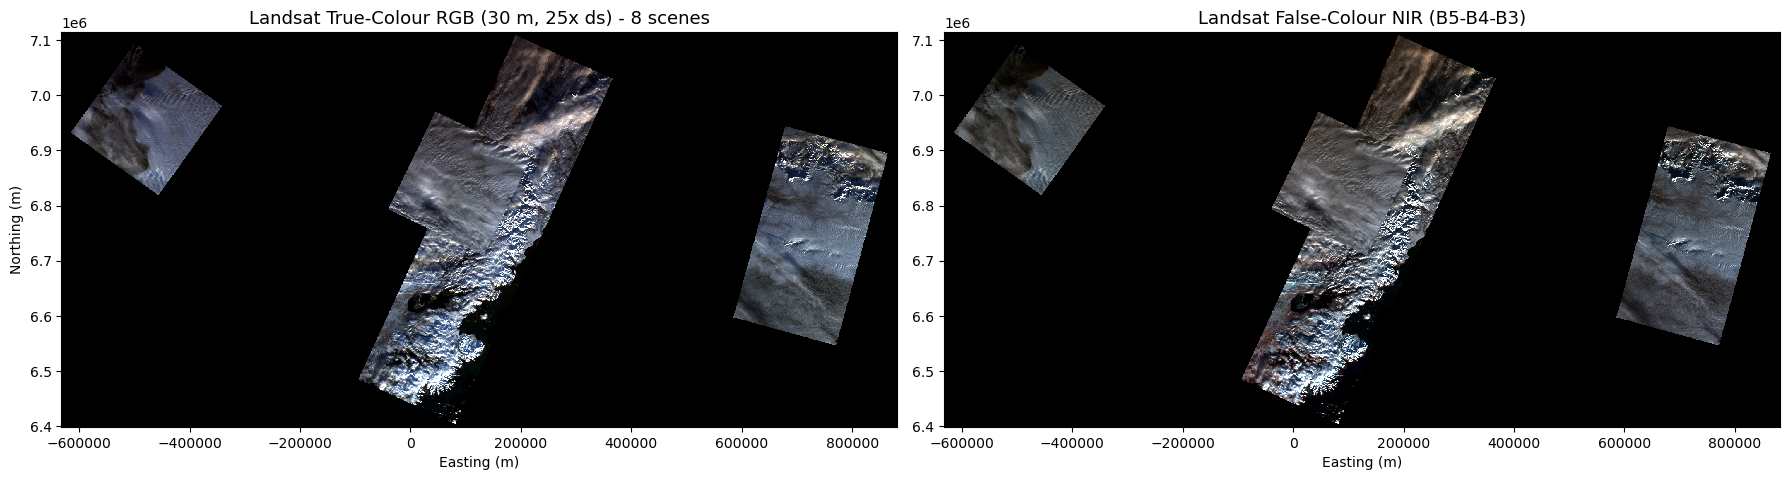

In [24]:
# CELL 6 - DISPLAY LANDSAT TRUE-COLOUR RGB (B4=R, B3=G, B2=B)
# Uses downsampled mosaic (mosaic_ds) to avoid MemoryError during rendering.

def make_rgb(r, g, b, lo_pct=2, hi_pct=98):
    out = np.zeros((*r.shape, 3), dtype=np.uint8)
    for i, ch in enumerate([r, g, b]):
        v = ch[np.isfinite(ch)]
        if len(v) == 0:
            continue
        lo, hi = np.percentile(v, [lo_pct, hi_pct])
        stretched = np.clip((ch - lo) / max(hi - lo, 1e-6), 0, 1)
        stretched = np.where(np.isfinite(ch), stretched, 0)
        out[:, :, i] = (stretched * 255).astype(np.uint8)
    return out


has_rgb_bands = all(b in mosaic_ds for b in ["B2", "B3", "B4"])

if has_rgb_bands:
    rgb = make_rgb(mosaic_ds["B4"], mosaic_ds["B3"], mosaic_ds["B2"])

    # Extent from the full-res mosaic transform
    full_h = mosaic_ds[next(iter(mosaic_ds))].shape[0] * ds_factor
    full_w = mosaic_ds[next(iter(mosaic_ds))].shape[1] * ds_factor
    l_extent = [
        landsat_tf.c,
        landsat_tf.c + full_w * landsat_tf.a,
        landsat_tf.f + full_h * landsat_tf.e,
        landsat_tf.f,
    ]

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    axes[0].imshow(rgb, extent=l_extent, interpolation="nearest")
    axes[0].set_title(f"Landsat True-Colour RGB (30 m, {ds_factor}x ds) - {len(scene_grids)} scenes", fontsize=13)
    axes[0].set_xlabel("Easting (m)"); axes[0].set_ylabel("Northing (m)")

    if "B5" in mosaic_ds:
        nir_fc = make_rgb(mosaic_ds["B5"], mosaic_ds["B4"], mosaic_ds["B3"])
        axes[1].imshow(nir_fc, extent=l_extent, interpolation="nearest")
        axes[1].set_title("Landsat False-Colour NIR (B5-B4-B3)", fontsize=13)
    else:
        axes[1].imshow(mosaic_ds["B4"], extent=l_extent, cmap="gray", interpolation="nearest")
        axes[1].set_title("Landsat B4 (Red)", fontsize=13)
    axes[1].set_xlabel("Easting (m)")

    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, "landsat_rgb_mosaic.png"), dpi=150, bbox_inches="tight")
    print("Saved landsat_rgb_mosaic.png")
    plt.show()
else:
    missing = [b for b in ["B2","B3","B4"] if b not in mosaic_ds]
    print(f"Cannot make RGB - missing bands: {missing}")
    print("Available bands:", sorted(mosaic_ds.keys()))


Saved landsat_scenes_rgb.png  (8 scenes)


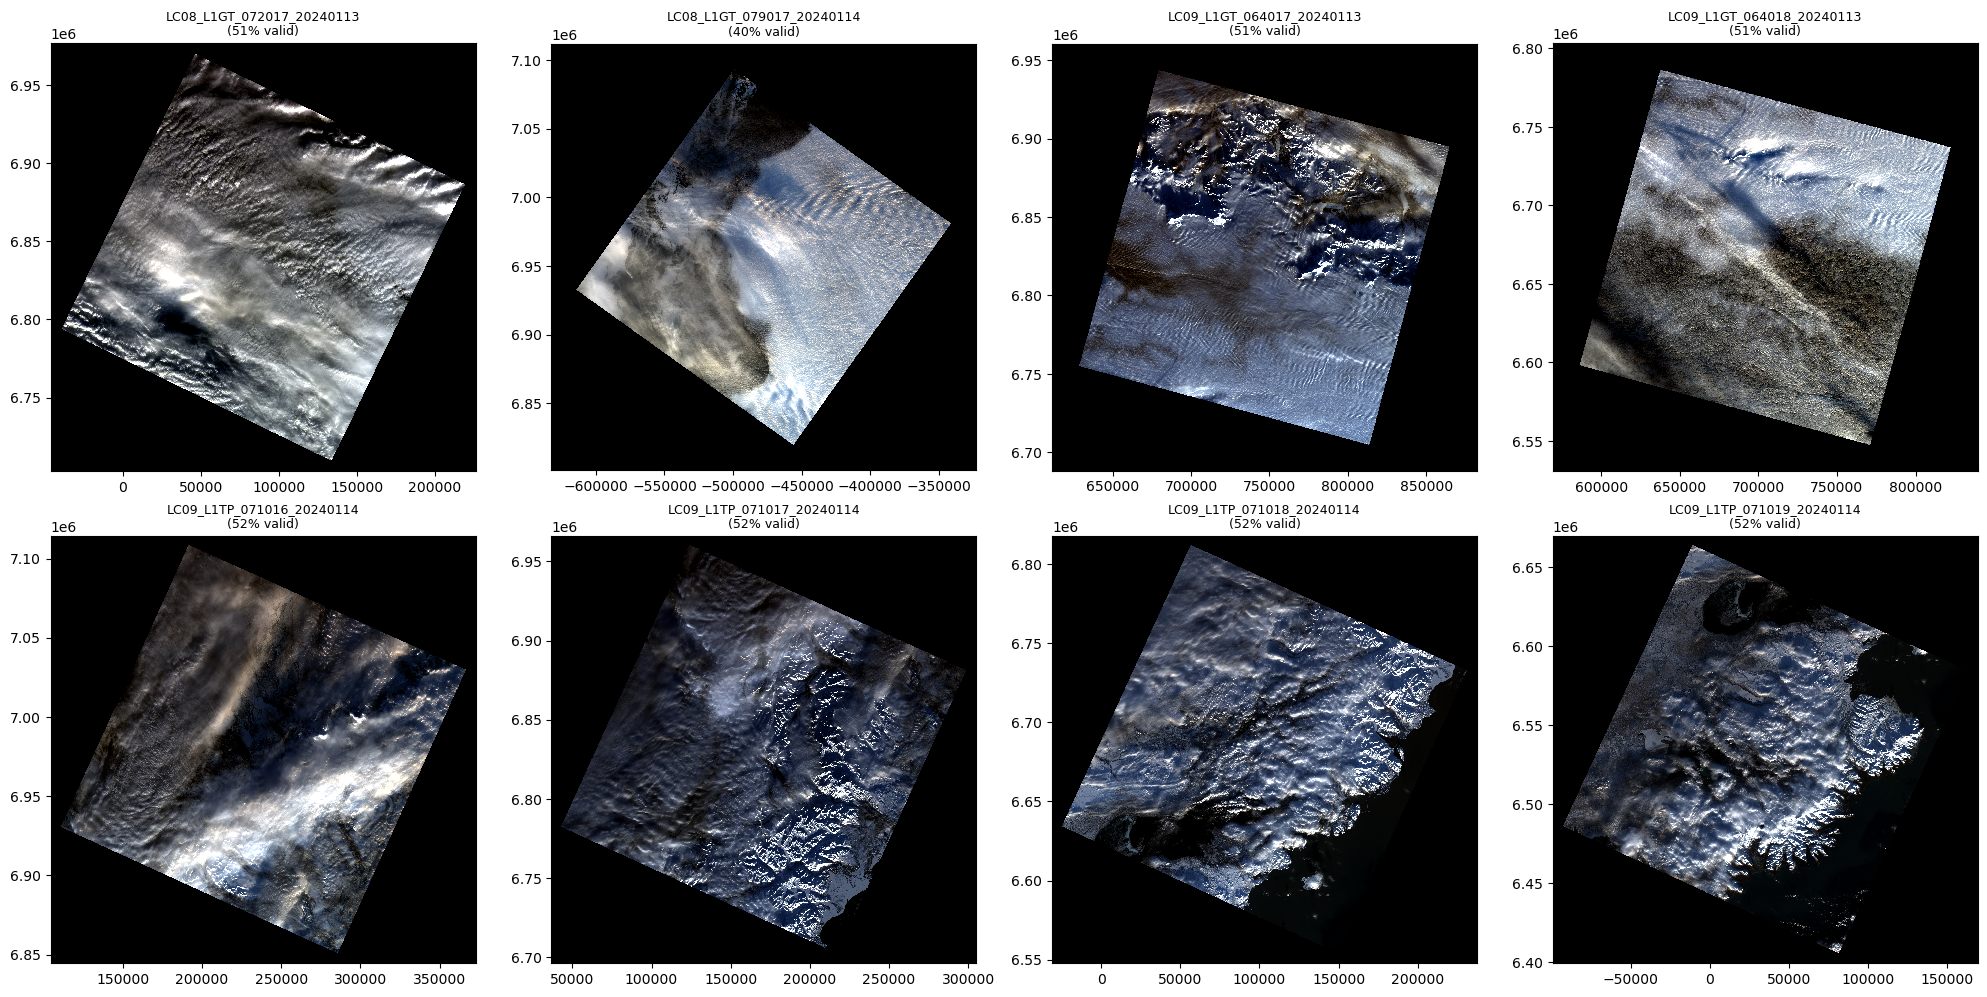

In [25]:
# CELL 7 - PER-SCENE LANDSAT RGB THUMBNAILS
# Reads per-scene GeoTIFFs from disk and downsamples for display.

THUMB_MAX_PX = 2000

n = len(scene_tif_paths)
if n > 0:
    cols = min(n, 4)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    if n == 1:
        axes = np.array([axes])
    axes = np.atleast_2d(axes)

    for idx, spath in enumerate(sorted(scene_tif_paths)):
        r, c = divmod(idx, cols)
        ax = axes[r, c]
        with rasterio.open(spath) as src:
            descs = [src.descriptions[i] for i in range(src.count)]
            t = src.transform
            sh, sw = src.height, src.width
            ext = [t.c, t.c + sw * t.a, t.f + sh * t.e, t.f]
            sf = max(1, max(sh, sw) // THUMB_MAX_PX)
            # Read at reduced resolution
            out_h = sh // sf
            out_w = sw // sf
            data = src.read(out_shape=(src.count, out_h, out_w))
            data = data.astype(np.float32)
            data[data == -9999.0] = np.nan

        # Find B2,B3,B4 indices
        b2i = descs.index("B2") if "B2" in descs else None
        b3i = descs.index("B3") if "B3" in descs else None
        b4i = descs.index("B4") if "B4" in descs else None

        sid = os.path.basename(spath).replace("scene_", "").replace(".tif", "")
        if b2i is not None and b3i is not None and b4i is not None:
            im = make_rgb(data[b4i], data[b3i], data[b2i])
            ax.imshow(im, extent=ext, interpolation="nearest")
        else:
            ax.imshow(data[0], extent=ext, cmap="gray", interpolation="nearest")

        vfrac = np.isfinite(data[0]).sum() / data[0].size
        ax.set_title(f"{sid}\n({vfrac:.0%} valid)", fontsize=9)

    for idx in range(n, rows * cols):
        r, c = divmod(idx, cols)
        axes[r, c].set_visible(False)

    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, "landsat_scenes_rgb.png"), dpi=120, bbox_inches="tight")
    print(f"Saved landsat_scenes_rgb.png  ({n} scenes)")
    plt.show()
else:
    print("No scene GeoTIFFs found.")


Saved viirs_bands_375m.png  (5 bands)


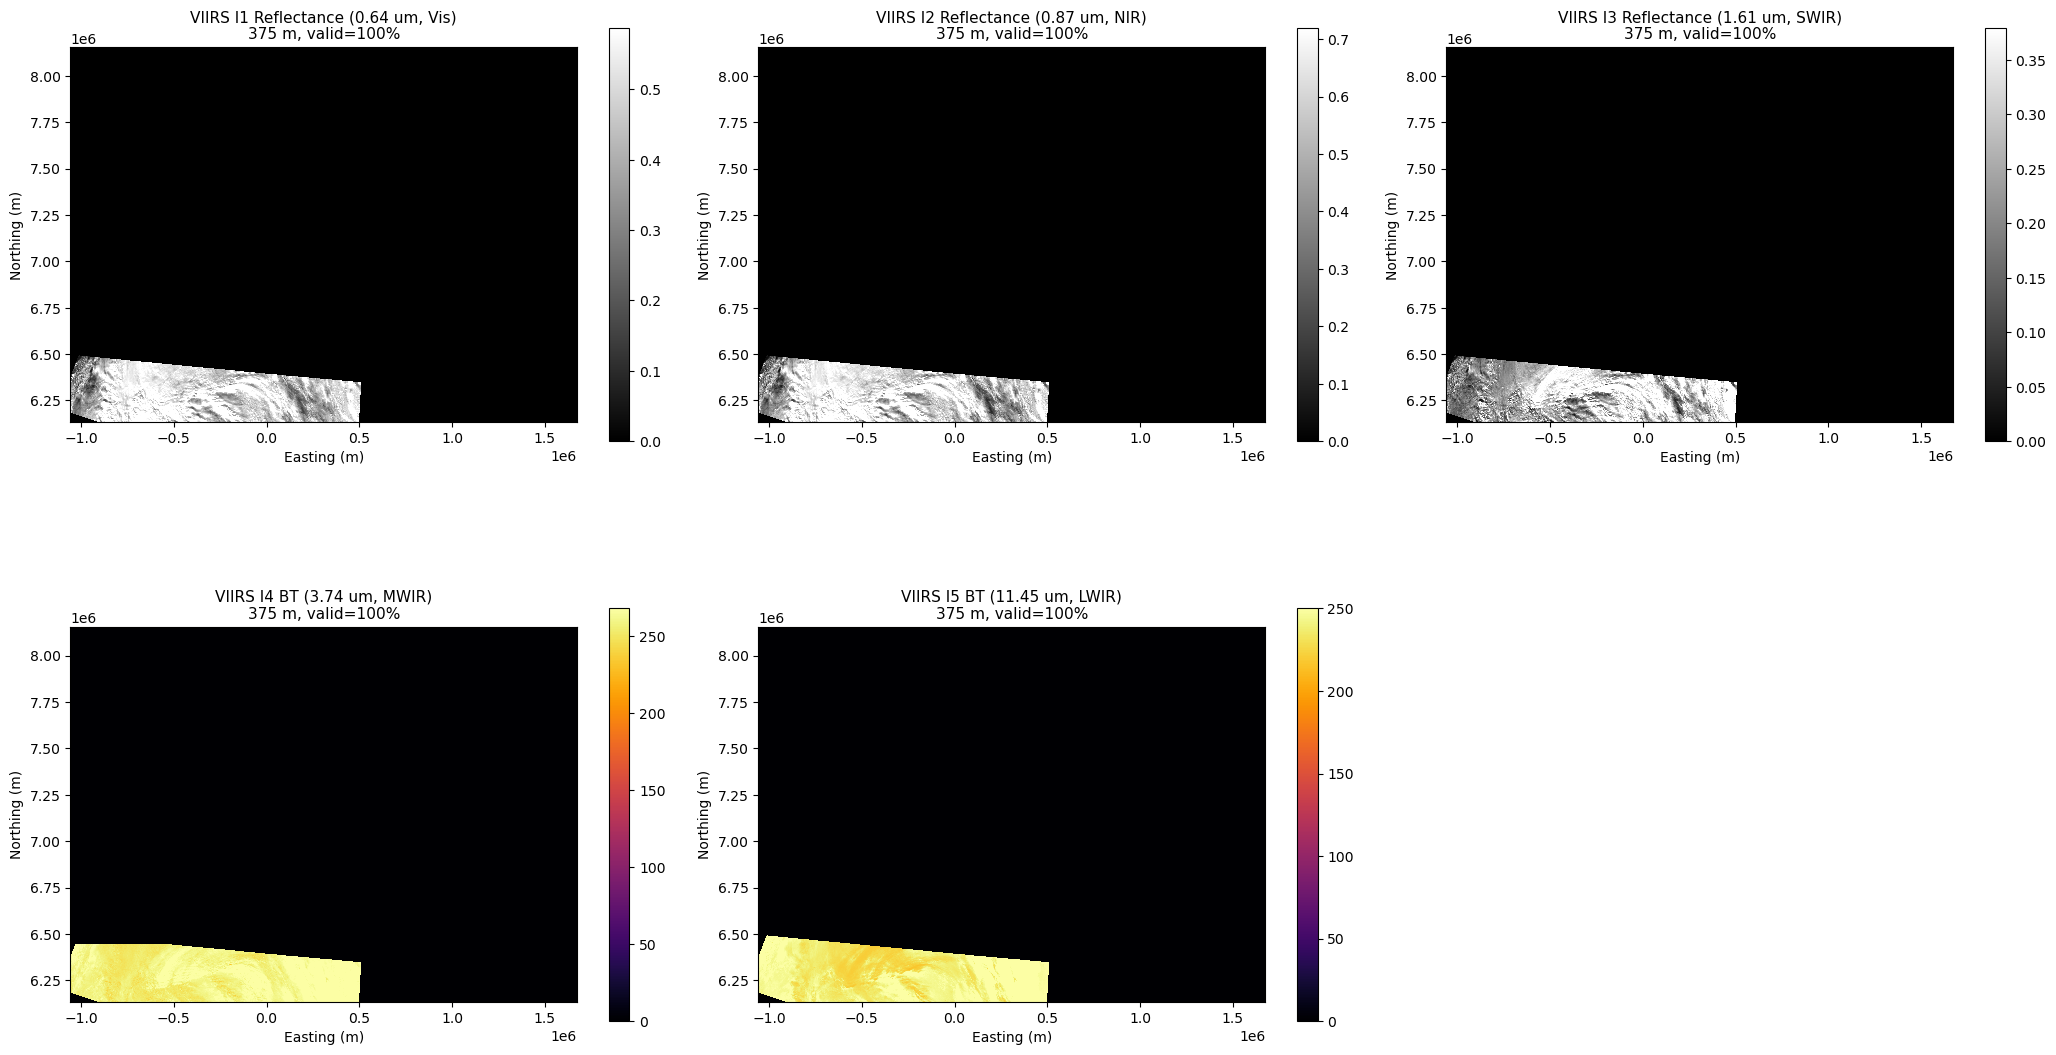

Saved viirs_angles_375m.png


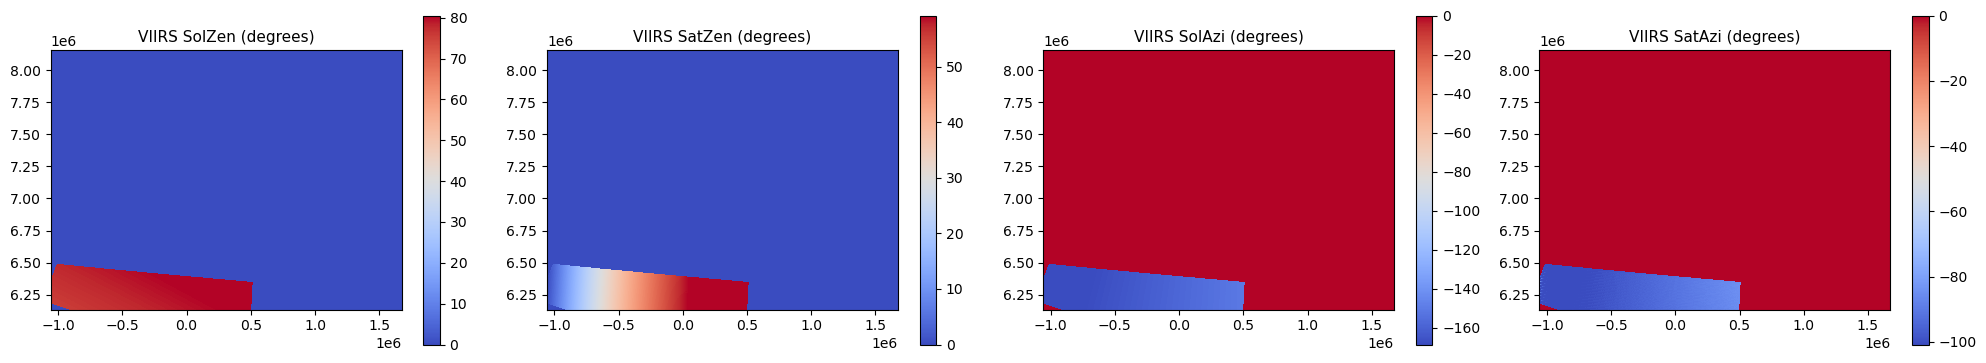

In [26]:
# CELL 8 - VIIRS I-BAND IMAGERY (375 m, full Alaska domain)
# Display each reprojected VIIRS I-band: I1-I3 Reflectance, I4-I5 Brightness Temp.

viirs_band_keys = [k for k in viirs_375 if k.startswith("I")]
viirs_angle_keys = [k for k in viirs_375 if not k.startswith("I")]

v_ext = [viirs_tf.c, viirs_tf.c + vw * viirs_tf.a,
         viirs_tf.f + vh * viirs_tf.e, viirs_tf.f]

if viirs_band_keys:
    nb = len(viirs_band_keys)
    cols_v = min(nb, 3)
    rows_v = (nb + cols_v - 1) // cols_v
    fig, axes = plt.subplots(rows_v, cols_v, figsize=(7 * cols_v, 6 * rows_v))
    if nb == 1:
        axes = np.array([axes])
    axes = np.atleast_2d(axes)

    band_labels = {
        "I1": "I1 Reflectance (0.64 um, Vis)",
        "I2": "I2 Reflectance (0.87 um, NIR)",
        "I3": "I3 Reflectance (1.61 um, SWIR)",
        "I4": "I4 BT (3.74 um, MWIR)",
        "I5": "I5 BT (11.45 um, LWIR)",
    }

    for idx, bk in enumerate(sorted(viirs_band_keys)):
        r, c = divmod(idx, cols_v)
        ax = axes[r, c]
        arr = viirs_375[bk]
        v = arr[np.isfinite(arr)]
        if len(v) > 0:
            lo, hi = np.percentile(v, [2, 98])
            cmap = "gray" if bk in ("I1", "I2", "I3") else "inferno"
            im = ax.imshow(arr, extent=v_ext, cmap=cmap, vmin=lo, vmax=hi, interpolation="nearest")
            plt.colorbar(im, ax=ax, shrink=0.7)
        else:
            ax.text(0.5, 0.5, "No valid data", transform=ax.transAxes, ha="center")
        label = band_labels.get(bk, bk)
        vfrac = np.isfinite(arr).sum() / arr.size
        ax.set_title(f"VIIRS {label}\n375 m, valid={vfrac:.0%}", fontsize=11)
        ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")

    for idx in range(nb, rows_v * cols_v):
        r, c = divmod(idx, cols_v)
        axes[r, c].set_visible(False)

    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, "viirs_bands_375m.png"), dpi=150, bbox_inches="tight")
    print(f"Saved viirs_bands_375m.png  ({nb} bands)")
    plt.show()

    # Also show angles in a separate figure
    if viirs_angle_keys:
        na = len(viirs_angle_keys)
        fig2, axes2 = plt.subplots(1, na, figsize=(5 * na, 5))
        if na == 1:
            axes2 = [axes2]
        for idx, ak in enumerate(viirs_angle_keys):
            arr = viirs_375[ak]
            v = arr[np.isfinite(arr)]
            lo, hi = (np.percentile(v, [2, 98]) if len(v) else (0, 1))
            im = axes2[idx].imshow(arr, extent=v_ext, cmap="coolwarm", vmin=lo, vmax=hi, interpolation="nearest")
            plt.colorbar(im, ax=axes2[idx], shrink=0.7)
            axes2[idx].set_title(f"VIIRS {ak} (degrees)", fontsize=11)
        plt.tight_layout()
        fig2.savefig(os.path.join(OUTPUT_DIR, "viirs_angles_375m.png"), dpi=120, bbox_inches="tight")
        print("Saved viirs_angles_375m.png")
        plt.show()
else:
    print("No VIIRS I-bands available - showing angles only")
    na = len(viirs_angle_keys)
    fig, axes = plt.subplots(1, min(na, 4), figsize=(20, 5))
    if na == 1:
        axes = [axes]
    for idx, ak in enumerate(viirs_angle_keys[:4]):
        arr = viirs_375[ak]
        v = arr[np.isfinite(arr)]
        lo, hi = (np.percentile(v, [2, 98]) if len(v) else (0, 1))
        im = axes[idx].imshow(arr, extent=v_ext, cmap="coolwarm", vmin=lo, vmax=hi, interpolation="nearest")
        plt.colorbar(im, ax=axes[idx], shrink=0.7)
        axes[idx].set_title(f"VIIRS {ak}", fontsize=11)
    plt.tight_layout()
    plt.show()

Saved overlay_viirs_landsat.png


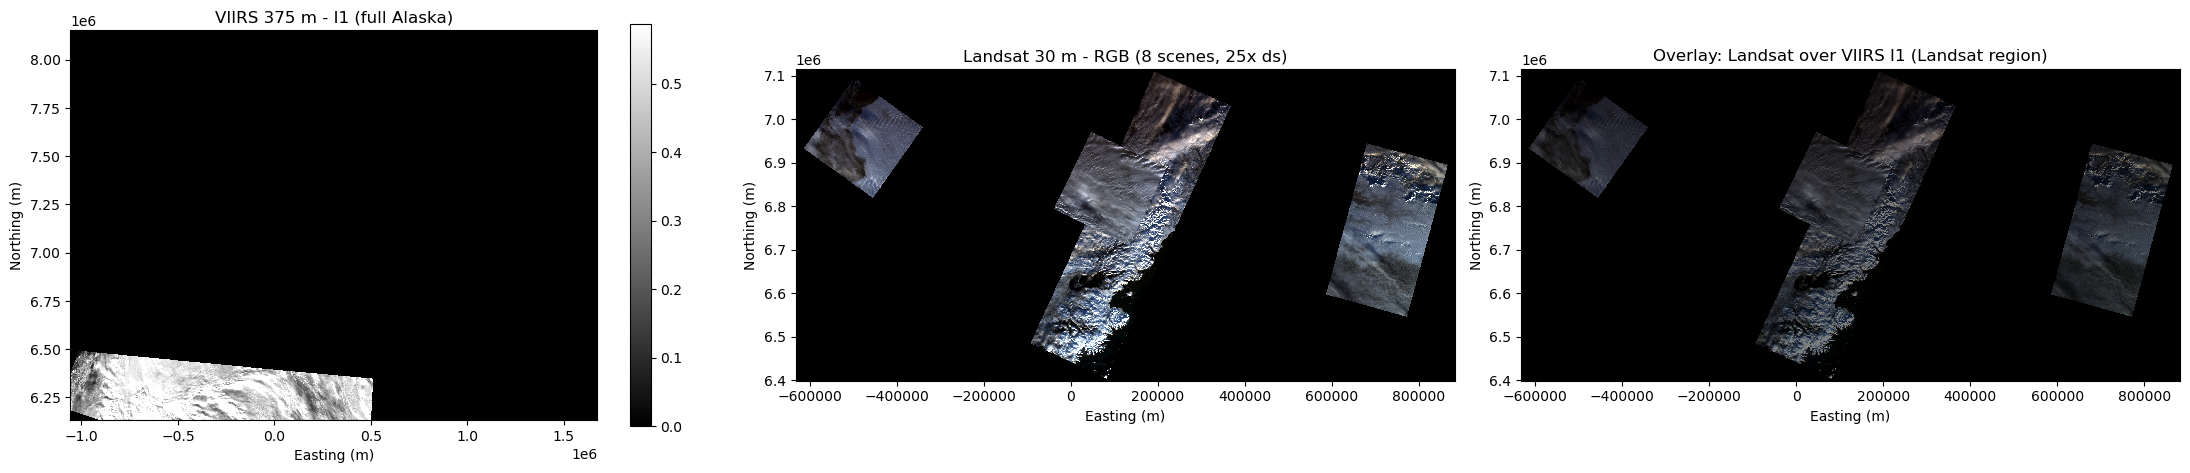

In [27]:
# CELL 9 - OVERLAY: LANDSAT 30 m OVER VIIRS 375 m (band-based, downsampled)
# Uses downsampled mosaic to avoid MemoryError.

from scipy.ndimage import zoom as nd_zoom

# Pick the best VIIRS layer for display (prefer I1 visible reflectance)
vk = "I1" if "I1" in viirs_375 else (viirs_band_keys[0] if viirs_band_keys else next(iter(viirs_375)))
v_data = viirs_375[vk]
is_band = vk.startswith("I")
v_cmap = "gray" if (is_band and int(vk[1]) <= 3) else ("inferno" if is_band else "viridis")

# Full-res Landsat extent (for axis labels)
full_h = mosaic_ds[next(iter(mosaic_ds))].shape[0] * ds_factor
full_w = mosaic_ds[next(iter(mosaic_ds))].shape[1] * ds_factor
l_ext = [landsat_tf.c, landsat_tf.c + full_w * landsat_tf.a,
         landsat_tf.f + full_h * landsat_tf.e, landsat_tf.f]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Panel 1: VIIRS band (full Alaska)
vv = v_data[np.isfinite(v_data)]
vlo, vhi = (np.percentile(vv, [2, 98]) if len(vv) else (0, 1))
im0 = axes[0].imshow(v_data, extent=v_ext, cmap=v_cmap, vmin=vlo, vmax=vhi, interpolation="nearest")
axes[0].set_title(f"VIIRS 375 m - {vk} (full Alaska)", fontsize=12)
plt.colorbar(im0, ax=axes[0], shrink=0.6)

# Panel 2: Landsat 30 m mosaic (downsampled)
if has_rgb_bands:
    axes[1].imshow(rgb, extent=l_ext, interpolation="nearest")
    axes[1].set_title(f"Landsat 30 m - RGB ({len(scene_grids)} scenes, {ds_factor}x ds)", fontsize=12)
elif "B5" in mosaic_ds:
    v = mosaic_ds["B5"]; vvl = v[np.isfinite(v)]
    lo, hi = (np.percentile(vvl, [2, 98]) if len(vvl) else (0, 1))
    axes[1].imshow(v, extent=l_ext, cmap="gray", vmin=lo, vmax=hi, interpolation="nearest")
    axes[1].set_title("Landsat 30 m - B5", fontsize=12)

# Panel 3: Overlay - crop VIIRS to Landsat region, downsample to match display
vc0 = max(0, int((l_ext[0] - viirs_tf.c) / viirs_tf.a))
vc1 = min(vw, int((l_ext[1] - viirs_tf.c) / viirs_tf.a))
vr0 = max(0, int((l_ext[3] - viirs_tf.f) / viirs_tf.e))
vr1 = min(vh, int((l_ext[2] - viirs_tf.f) / viirs_tf.e))
v_crop = v_data[vr0:vr1, vc0:vc1]

# Upsample VIIRS to match downsampled Landsat (not full 30m!)
scale = VIIRS_RES / (LANDSAT_RES * ds_factor)
v_up = nd_zoom(v_crop, scale, order=0)
lh_ds, lw_ds = mosaic_ds[next(iter(mosaic_ds))].shape
mh = min(v_up.shape[0], lh_ds); mw = min(v_up.shape[1], lw_ds)

vuv = v_up[np.isfinite(v_up)]
vulo, vuhi = (np.percentile(vuv, [2, 98]) if len(vuv) else (0, 1))
axes[2].imshow(v_up[:mh, :mw], extent=l_ext, cmap=v_cmap,
               vmin=vulo, vmax=vuhi, interpolation="nearest")
if has_rgb_bands:
    axes[2].imshow(rgb[:mh, :mw], extent=l_ext, alpha=0.5, interpolation="nearest")
elif "B5" in mosaic_ds:
    axes[2].imshow(mosaic_ds["B5"][:mh, :mw], extent=l_ext, cmap="gray",
                   vmin=lo, vmax=hi, alpha=0.5, interpolation="nearest")
axes[2].set_title(f"Overlay: Landsat over VIIRS {vk} (Landsat region)", fontsize=12)

for ax in axes:
    ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "overlay_viirs_landsat.png"), dpi=150, bbox_inches="tight")
print("Saved overlay_viirs_landsat.png")
plt.show()


Saved reprojection_summary_221.png


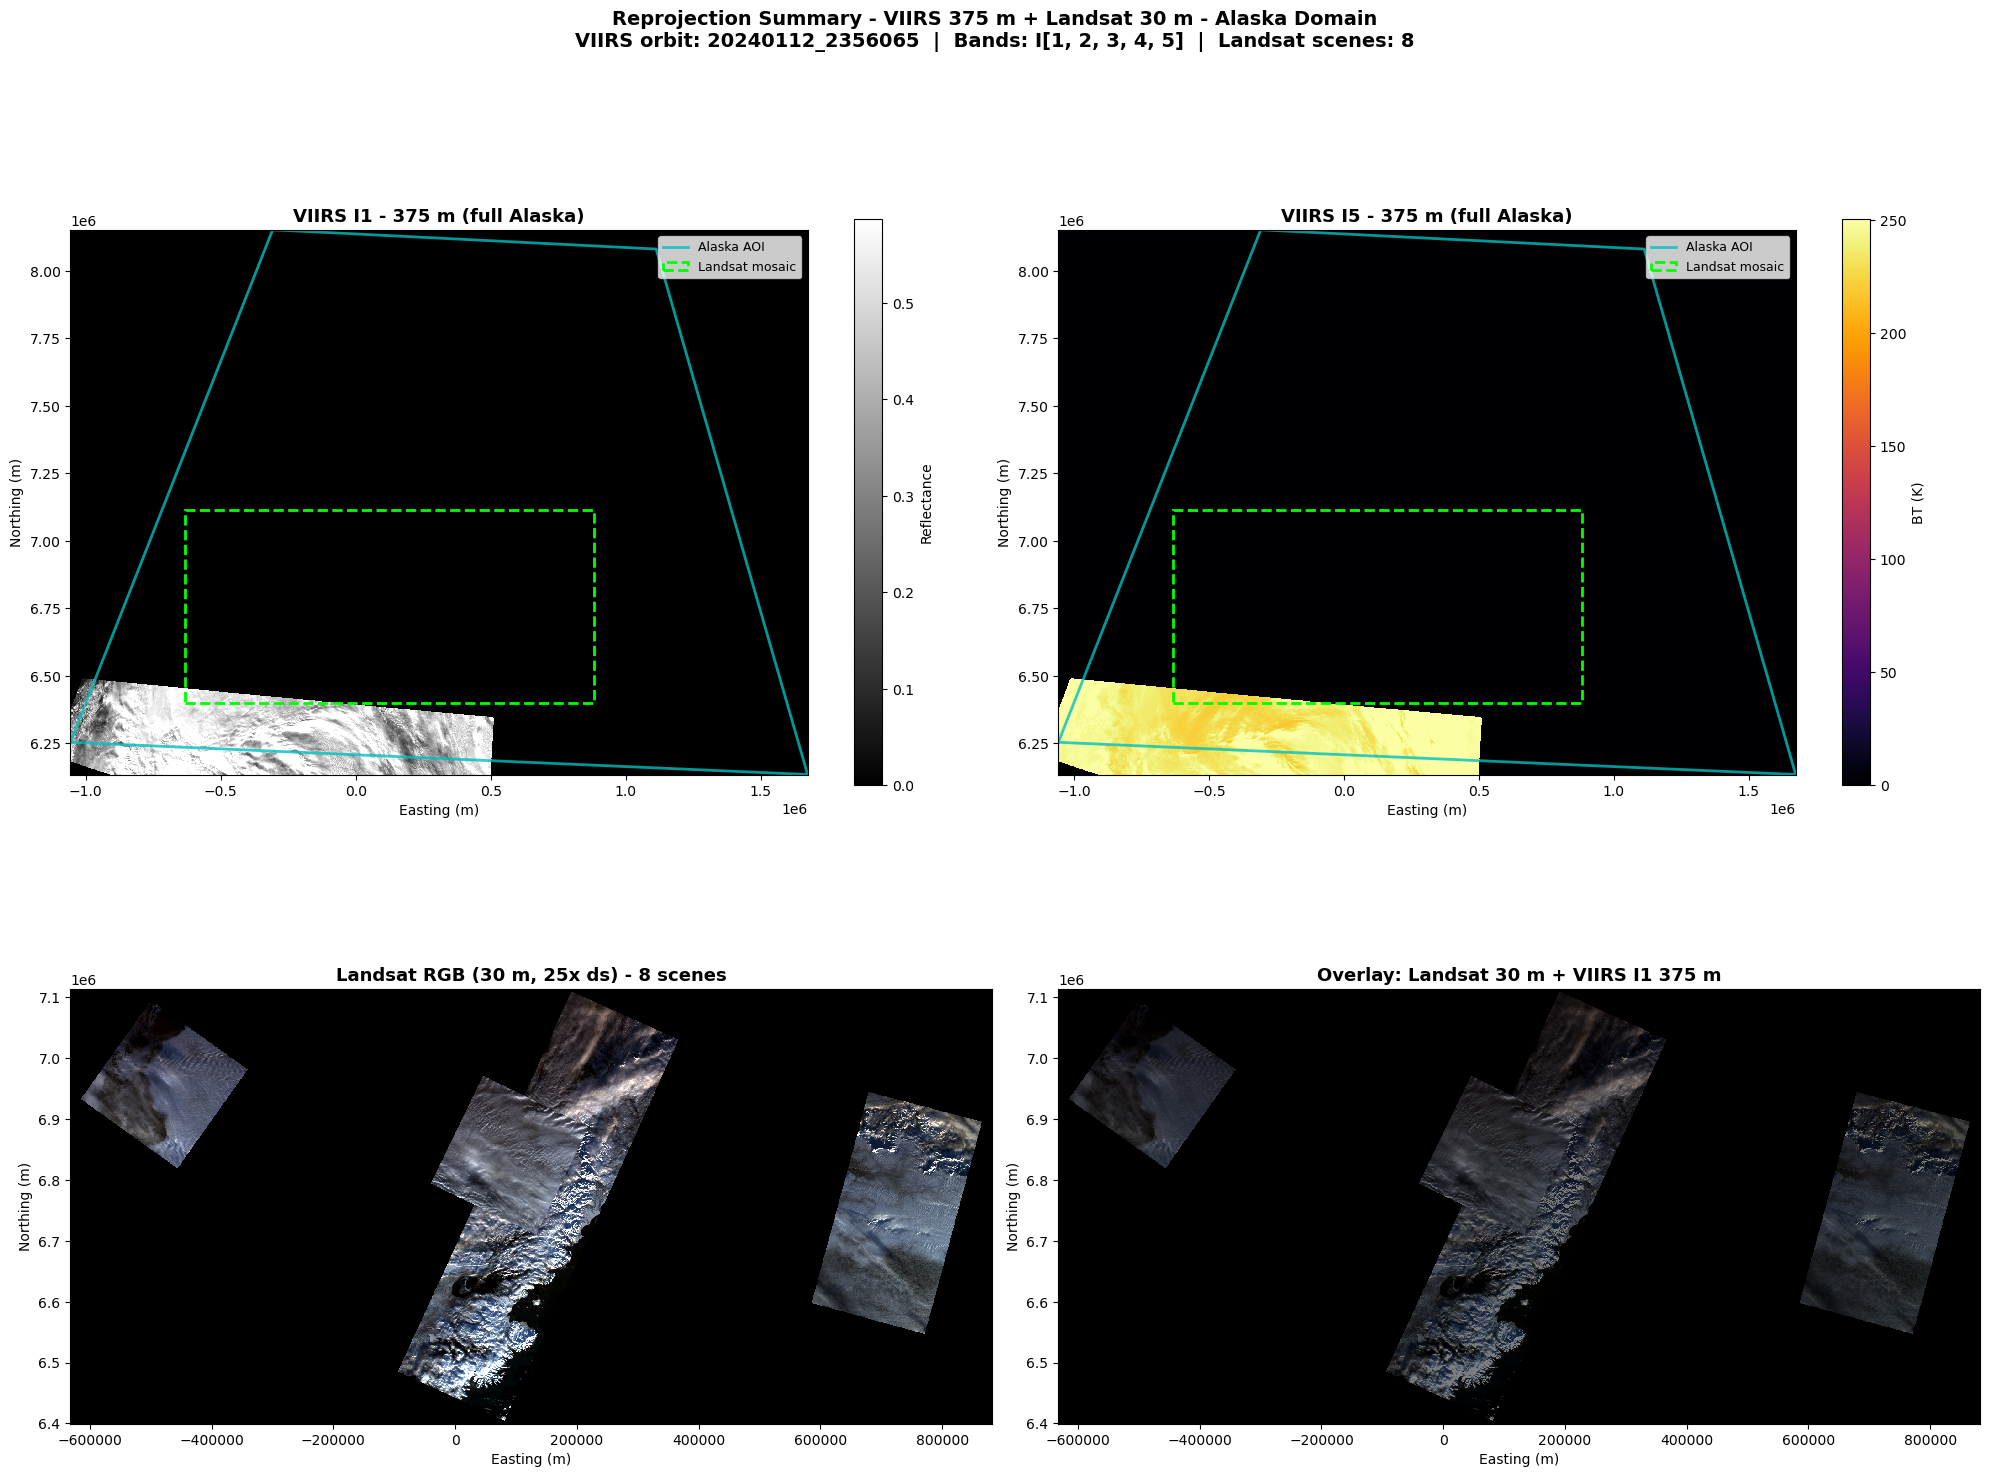

In [28]:
# CELL 10 - SUMMARY FIGURE: 2x2 (all reprojected data with AOI)
# Uses downsampled Landsat mosaic (mosaic_ds) to avoid MemoryError.

from scipy.ndimage import zoom as nd_zoom
from matplotlib.patches import Rectangle

vis_key = "I1" if "I1" in viirs_375 else (viirs_band_keys[0] if viirs_band_keys else "SolZen")
therm_key = "I5" if "I5" in viirs_375 else ("I4" if "I4" in viirs_375 else vis_key)

fig = plt.figure(figsize=(20, 16))

# (2,2,1) VIIRS Visible Band
ax1 = fig.add_subplot(2, 2, 1)
d1 = viirs_375[vis_key]
v1 = d1[np.isfinite(d1)]
lo1, hi1 = (np.percentile(v1, [2, 98]) if len(v1) else (0, 1))
cmap1 = "gray" if vis_key.startswith("I") and int(vis_key[1]) <= 3 else "inferno"
im1 = ax1.imshow(d1, extent=v_ext, cmap=cmap1, vmin=lo1, vmax=hi1, interpolation="nearest")
plt.colorbar(im1, ax=ax1, shrink=0.7, label="Reflectance" if int(vis_key[1]) <= 3 else "BT (K)")
ax1.set_title(f"VIIRS {vis_key} - 375 m (full Alaska)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Easting (m)"); ax1.set_ylabel("Northing (m)")

# (2,2,2) VIIRS Thermal Band
ax2 = fig.add_subplot(2, 2, 2)
d2 = viirs_375[therm_key]
v2 = d2[np.isfinite(d2)]
lo2, hi2 = (np.percentile(v2, [2, 98]) if len(v2) else (0, 1))
cmap2 = "inferno" if therm_key in ("I4", "I5") else "gray"
im2 = ax2.imshow(d2, extent=v_ext, cmap=cmap2, vmin=lo2, vmax=hi2, interpolation="nearest")
plt.colorbar(im2, ax=ax2, shrink=0.7, label="BT (K)" if therm_key in ("I4","I5") else "Reflectance")
ax2.set_title(f"VIIRS {therm_key} - 375 m (full Alaska)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Easting (m)"); ax2.set_ylabel("Northing (m)")

# (2,2,3) Landsat RGB Mosaic (downsampled)
ax3 = fig.add_subplot(2, 2, 3)
full_h = mosaic_ds[next(iter(mosaic_ds))].shape[0] * ds_factor
full_w = mosaic_ds[next(iter(mosaic_ds))].shape[1] * ds_factor
l_ext_s = [landsat_tf.c, landsat_tf.c + full_w * landsat_tf.a,
           landsat_tf.f + full_h * landsat_tf.e, landsat_tf.f]
if has_rgb_bands:
    ax3.imshow(rgb, extent=l_ext_s, interpolation="nearest")
    ax3.set_title(f"Landsat RGB (30 m, {ds_factor}x ds) - {len(scene_grids)} scenes", fontsize=13, fontweight="bold")
else:
    bk3 = next(iter(mosaic_ds))
    d3 = mosaic_ds[bk3]; v3 = d3[np.isfinite(d3)]
    lo3, hi3 = (np.percentile(v3, [2, 98]) if len(v3) else (0, 1))
    ax3.imshow(d3, extent=l_ext_s, cmap="gray", vmin=lo3, vmax=hi3, interpolation="nearest")
    ax3.set_title(f"Landsat {bk3} (30 m)", fontsize=13, fontweight="bold")
ax3.set_xlabel("Easting (m)"); ax3.set_ylabel("Northing (m)")

# (2,2,4) Overlay - VIIRS + Landsat (downsampled)
ax4 = fig.add_subplot(2, 2, 4)
vc0s = max(0, int((l_ext_s[0] - viirs_tf.c) / viirs_tf.a))
vc1s = min(vw, int((l_ext_s[1] - viirs_tf.c) / viirs_tf.a))
vr0s = max(0, int((l_ext_s[3] - viirs_tf.f) / viirs_tf.e))
vr1s = min(vh, int((l_ext_s[2] - viirs_tf.f) / viirs_tf.e))
v_crop_s = viirs_375[vis_key][vr0s:vr1s, vc0s:vc1s]

scale_s = VIIRS_RES / (LANDSAT_RES * ds_factor)
v_up_s = nd_zoom(v_crop_s, scale_s, order=0)
lh_ds, lw_ds = mosaic_ds[next(iter(mosaic_ds))].shape
mh_s = min(v_up_s.shape[0], lh_ds); mw_s = min(v_up_s.shape[1], lw_ds)
vus = v_up_s[np.isfinite(v_up_s)]
vulo_s, vuhi_s = (np.percentile(vus, [2, 98]) if len(vus) else (0, 1))

ax4.imshow(v_up_s[:mh_s, :mw_s], extent=l_ext_s, cmap=cmap1,
           vmin=vulo_s, vmax=vuhi_s, interpolation="nearest")
if has_rgb_bands:
    ax4.imshow(rgb[:mh_s, :mw_s], extent=l_ext_s, alpha=0.5, interpolation="nearest")
ax4.set_title(f"Overlay: Landsat 30 m + VIIRS {vis_key} 375 m", fontsize=13, fontweight="bold")
ax4.set_xlabel("Easting (m)"); ax4.set_ylabel("Northing (m)")

# Draw Alaska AOI box on VIIRS panels
to_utm_aoi = Transformer.from_crs("EPSG:4326", utm_crs, always_xy=True)
aoi_corners_utm = [to_utm_aoi.transform(lon, lat) for lon, lat in [
    (ALASKA_BBOX[2], ALASKA_BBOX[0]), (ALASKA_BBOX[3], ALASKA_BBOX[0]),
    (ALASKA_BBOX[3], ALASKA_BBOX[1]), (ALASKA_BBOX[2], ALASKA_BBOX[1]),
    (ALASKA_BBOX[2], ALASKA_BBOX[0]),
]]
aoi_xs = [c[0] for c in aoi_corners_utm]
aoi_ys = [c[1] for c in aoi_corners_utm]
for ax in [ax1, ax2]:
    ax.plot(aoi_xs, aoi_ys, 'c-', lw=2, alpha=0.8, label="Alaska AOI")
    ax.add_patch(Rectangle((l_ext_s[0], l_ext_s[2]),
                            l_ext_s[1] - l_ext_s[0], l_ext_s[3] - l_ext_s[2],
                            linewidth=2, edgecolor='lime', facecolor='none',
                            linestyle='--', label='Landsat mosaic'))
    ax.legend(loc='upper right', fontsize=9)

plt.suptitle(f"Reprojection Summary - VIIRS 375 m + Landsat 30 m - Alaska Domain\n"
             f"VIIRS orbit: {orb['orbit_key']}  |  Bands: I{orb['sdr_bands']}  |  "
             f"Landsat scenes: {len(scene_grids)}",
             fontsize=14, fontweight="bold", y=1.01)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "reprojection_summary_221.png"), dpi=150, bbox_inches="tight")
print("Saved reprojection_summary_221.png")
plt.show()


In [32]:
# CELL 10 - EXPORT PROJECTED GeoTIFFs

# VIIRS 375 m - full Alaska domain
viirs_date = orb["orbit_key"].split("_")[0]
viirs_out = os.path.join(OUTPUT_DIR, f"viirs_375m_{viirs_date}.tif")
fk = next(iter(viirs_375))
h_, w_ = viirs_375[fk].shape
with rasterio.open(viirs_out, "w", driver="GTiff", height=h_, width=w_,
                   count=len(viirs_375), dtype=np.float32,
                   crs=utm_crs, transform=viirs_tf, nodata=-9999.0) as dst:
    for i, (name, arr) in enumerate(tqdm(viirs_375.items(), desc="Writing VIIRS bands"), 1):
        dst.write(np.where(np.isfinite(arr), arr, -9999.0).astype(np.float32), i)
        dst.set_band_description(i, name)
print(f"VIIRS: {os.path.basename(viirs_out)}  ({len(viirs_375)} bands, {w_}x{h_})")

# Landsat 30 m mosaic already saved in Cell 5
print(f"Landsat mosaic: {LANDSAT_MOSAIC_PATH}  (already saved)")
print(f"Per-scene GeoTIFFs: {SCENE_CHUNK_DIR}/")

print(f"\nAll exports in: {OUTPUT_DIR}")


Writing VIIRS bands:   0%|          | 0/9 [00:00<?, ?it/s]

VIIRS: viirs_375m_20240112.tif  (9 bands, 7284x5382)
Landsat mosaic: d:\Reprojection\outputs\landsat_30m_mosaic.tif  (already saved)
Per-scene GeoTIFFs: d:\Reprojection\outputs\landsat_scene_chunks/

All exports in: d:\Reprojection\outputs


In [39]:
# CELL 10b - EXPORT KMZ (VIIRS + Landsat overlay for Google Earth)
# Creates a KMZ with VIIRS as base layer and Landsat RGB overlaid on top.

import zipfile
from io import BytesIO
from PIL import Image

to_ll_kmz = Transformer.from_crs(utm_crs, "EPSG:4326", always_xy=True)

# --- VIIRS layer (I1 grayscale or false-colour) ---------------------------
vk_kmz = "I1" if "I1" in viirs_375 else next(k for k in viirs_375 if k.startswith("I"))
v_arr = viirs_375[vk_kmz].copy()
vv = v_arr[np.isfinite(v_arr)]
vlo, vhi = np.percentile(vv, [2, 98]) if len(vv) else (0, 1)
v_norm = np.clip((v_arr - vlo) / (vhi - vlo + 1e-10), 0, 1)
v_norm[~np.isfinite(v_arr)] = 0
v_img = (v_norm * 255).astype(np.uint8)

# VIIRS extent in lat/lon
v_x0 = viirs_tf.c
v_x1 = viirs_tf.c + vw * viirs_tf.a
v_y0 = viirs_tf.f + vh * viirs_tf.e  # bottom (south)
v_y1 = viirs_tf.f                     # top (north)
v_lon0, v_lat0 = to_ll_kmz.transform(v_x0, v_y0)
v_lon1, v_lat1 = to_ll_kmz.transform(v_x1, v_y1)

# Save VIIRS PNG
viirs_png = BytesIO()
Image.fromarray(v_img, mode="L").save(viirs_png, format="PNG")
viirs_png.seek(0)

# --- Landsat RGB layer (downsampled mosaic) --------------------------------
has_rgb = all(b in mosaic_ds for b in ["B4", "B3", "B2"])
if has_rgb:
    r = mosaic_ds["B4"].copy()
    g = mosaic_ds["B3"].copy()
    b_ch = mosaic_ds["B2"].copy()
    for ch in [r, g, b_ch]:
        ch[~np.isfinite(ch)] = 0
    # Percentile stretch per channel
    def stretch(arr):
        vv = arr[arr > 0]
        if len(vv) == 0:
            return np.zeros_like(arr, dtype=np.uint8)
        lo, hi = np.percentile(vv, [2, 98])
        return np.clip((arr - lo) / (hi - lo + 1e-10) * 255, 0, 255).astype(np.uint8)
    rgb_arr = np.stack([stretch(r), stretch(g), stretch(b_ch)], axis=-1)
    # Alpha channel: transparent where all bands are 0
    alpha = np.where((r > 0) | (g > 0) | (b_ch > 0), 200, 0).astype(np.uint8)
    rgba_arr = np.dstack([rgb_arr, alpha])
else:
    # Fallback: use B5 or first available band as grayscale
    bk = "B5" if "B5" in mosaic_ds else next(iter(mosaic_ds))
    l_arr = mosaic_ds[bk].copy()
    lv = l_arr[np.isfinite(l_arr)]
    llo, lhi = np.percentile(lv, [2, 98]) if len(lv) else (0, 1)
    l_norm = np.clip((l_arr - llo) / (lhi - llo + 1e-10), 0, 1)
    l_norm[~np.isfinite(l_arr)] = 0
    l_u8 = (l_norm * 255).astype(np.uint8)
    alpha = np.where(l_u8 > 0, 200, 0).astype(np.uint8)
    rgba_arr = np.dstack([l_u8, l_u8, l_u8, alpha])

# Landsat extent in lat/lon
full_h_kmz = mosaic_ds[next(iter(mosaic_ds))].shape[0] * ds_factor
full_w_kmz = mosaic_ds[next(iter(mosaic_ds))].shape[1] * ds_factor
l_x0 = landsat_tf.c
l_x1 = landsat_tf.c + full_w_kmz * landsat_tf.a
l_y0 = landsat_tf.f + full_h_kmz * landsat_tf.e
l_y1 = landsat_tf.f
l_lon0, l_lat0 = to_ll_kmz.transform(l_x0, l_y0)
l_lon1, l_lat1 = to_ll_kmz.transform(l_x1, l_y1)

landsat_png = BytesIO()
Image.fromarray(rgba_arr, mode="RGBA").save(landsat_png, format="PNG")
landsat_png.seek(0)

# --- Build KMZ -------------------------------------------------------------
kml_content = f"""<?xml version="1.0" encoding="UTF-8"?>
<kml xmlns="http://www.opengis.net/kml/2.2">
<Document>
  <name>VIIRS + Landsat Overlay</name>
  <description>VIIRS 375m ({vk_kmz}) with Landsat 30m RGB overlay</description>

  <Folder>
    <name>VIIRS {vk_kmz} (375 m)</name>
    <GroundOverlay>
      <name>VIIRS {vk_kmz}</name>
      <color>ffffffff</color>
      <Icon><href>viirs.png</href></Icon>
      <LatLonBox>
        <north>{v_lat1:.6f}</north>
        <south>{v_lat0:.6f}</south>
        <east>{v_lon1:.6f}</east>
        <west>{v_lon0:.6f}</west>
      </LatLonBox>
    </GroundOverlay>
  </Folder>

  <Folder>
    <name>Landsat 30 m RGB (all scenes merged)</name>
    <GroundOverlay>
      <name>Landsat RGB Mosaic</name>
      <color>ffffffff</color>
      <Icon><href>landsat.png</href></Icon>
      <LatLonBox>
        <north>{l_lat1:.6f}</north>
        <south>{l_lat0:.6f}</south>
        <east>{l_lon1:.6f}</east>
        <west>{l_lon0:.6f}</west>
      </LatLonBox>
    </GroundOverlay>
  </Folder>

</Document>
</kml>
"""

kmz_path = os.path.join(OUTPUT_DIR, f"viirs_landsat_overlay_{orb['orbit_key'].split('_')[0]}.kmz")
with zipfile.ZipFile(kmz_path, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.writestr("doc.kml", kml_content)
    zf.writestr("viirs.png", viirs_png.getvalue())
    zf.writestr("landsat.png", landsat_png.getvalue())

print(f"KMZ saved: {kmz_path}")
print(f"  VIIRS layer : {vk_kmz} ({vh}x{vw})")
print(f"  Landsat layer: {'RGB (B4/B3/B2)' if has_rgb else bk} ({rgba_arr.shape[1]}x{rgba_arr.shape[0]})")
print(f"  VIIRS bbox   : [{v_lat0:.2f}, {v_lat1:.2f}] x [{v_lon0:.2f}, {v_lon1:.2f}]")
print(f"  Landsat bbox : [{l_lat0:.2f}, {l_lat1:.2f}] x [{l_lon0:.2f}, {l_lon1:.2f}]")
print(f"\nOpen in Google Earth to see Landsat overlaid on VIIRS.")

KMZ saved: d:\Reprojection\outputs\viirs_landsat_overlay_20240112.kmz
  VIIRS layer : I1 (5382x7284)
  Landsat layer: RGB (B4/B3/B2) (2019x953)
  VIIRS bbox   : [53.02, 70.52] x [-170.42, -114.03]
  Landsat bbox : [56.35, 63.94] x [-165.45, -139.20]

Open in Google Earth to see Landsat overlaid on VIIRS.


In [36]:
# CELL 11 - EXTRACT SAMPLE DATA FROM REPROJECTED GRIDS
# Extract pixel values from the reprojected VIIRS (375 m) and Landsat (30 m)
# grids across the overlap region. Displays tables in-notebook.

import pandas as pd
from IPython.display import display, HTML

# -- Find overlap region (where both VIIRS and Landsat have valid data) ----
to_ll = Transformer.from_crs(utm_crs, "EPSG:4326", always_xy=True)

# Landsat mosaic extent in UTM coords
mosaic_x0 = landsat_tf.c
mosaic_y0 = landsat_tf.f + mosaic_h * landsat_tf.e  # e is negative
mosaic_x1 = landsat_tf.c + mosaic_w * landsat_tf.a
mosaic_y1 = landsat_tf.f

# VIIRS grid dimensions
vh, vw = viirs_375[next(iter(viirs_375))].shape
fk = next(iter(viirs_375))

# Mosaic dict from downsampled (read back from disk if needed)
if "mosaic" not in dir() or mosaic is None:
    mosaic = mosaic_ds

# Grid of sample points across the Landsat mosaic extent
n_samples_x, n_samples_y = 20, 15
sample_xs = np.linspace(mosaic_x0 + 5000, mosaic_x1 - 5000, n_samples_x)
sample_ys = np.linspace(mosaic_y0 + 5000, mosaic_y1 - 5000, n_samples_y)

# Map short viirs_375 keys to user-facing column names
angle_col_map = {
    "SolZen": "Solar_Zenith_Angle",
    "SatZen": "Satellite_Zenith_Angle",
    "SolAzi": "Solar_Azimuth_Angle",
    "SatAzi": "Satellite_Azimuth_Angle",
}

rows = []
for xu in tqdm(sample_xs, desc="Extracting sample pixels"):
    for yu in sample_ys:
        # VIIRS pixel coords
        vc = int((xu - viirs_tf.c) / viirs_tf.a)
        vr = int((yu - viirs_tf.f) / viirs_tf.e)
        if not (0 <= vr < vh and 0 <= vc < vw):
            continue

        # Check VIIRS has valid data at this point (any field)
        first_viirs = viirs_375[fk]
        if not np.isfinite(first_viirs[vr, vc]):
            continue

        # Landsat mosaic pixel coords (use downsampled grid coords)
        lc = int((xu - landsat_tf.c) / landsat_tf.a) // ds_factor
        lr = int((yu - landsat_tf.f) / landsat_tf.e) // ds_factor
        ds_h, ds_w = mosaic[next(iter(mosaic))].shape
        if not (0 <= lr < ds_h and 0 <= lc < ds_w):
            continue

        # Check Landsat has valid data (at least B1)
        if "B1" in mosaic and not np.isfinite(mosaic["B1"][lr, lc]):
            continue

        # Convert to lat/lon
        lon_pt, lat_pt = to_ll.transform(xu, yu)

        # Determine data availability flags
        has_viirs = any(
            np.isfinite(viirs_375[k][vr, vc])
            for k in viirs_375 if k.startswith("I") and 0 <= vr < viirs_375[k].shape[0] and 0 <= vc < viirs_375[k].shape[1]
        )
        has_landsat = any(
            0 <= lr < mosaic[b].shape[0] and 0 <= lc < mosaic[b].shape[1] and np.isfinite(mosaic[b][lr, lc])
            for b in mosaic
        )

        row = {
            "VIIRS_Acquisition_Date": orb["orbit_key"].split("_")[0],
            "Lat": round(lat_pt, 4),
            "Lon": round(lon_pt, 4),
            "Pixel_Row": vr,
            "Pixel_Col": vc,
            "Has_VIIRS": has_viirs,
            "Has_Landsat": has_landsat,
            "Has_Both": has_viirs and has_landsat,
        }

        # VIIRS angles
        for short_key, col_name in angle_col_map.items():
            if short_key in viirs_375:
                grid = viirs_375[short_key]
                if 0 <= vr < grid.shape[0] and 0 <= vc < grid.shape[1]:
                    val = grid[vr, vc]
                    row[col_name] = round(float(val), 4) if np.isfinite(val) else None

        # VIIRS I-bands (from GIMGO-SVI)
        for b in range(1, 6):
            key = f"I{b}"
            if key in viirs_375:
                val = viirs_375[key][vr, vc]
                row[f"Band{b}"] = round(float(val), 6) if np.isfinite(val) else None
            else:
                row[f"Band{b}"] = None

        # Landsat bands at this location
        for bname in sorted(mosaic.keys()):
            g = mosaic[bname]
            if 0 <= lr < g.shape[0] and 0 <= lc < g.shape[1]:
                val = g[lr, lc]
                row[f"Landsat_{bname}"] = round(float(val), 2) if np.isfinite(val) else None

        # Placeholders for user-filled columns
        row["Vegetation_Type"] = None
        row["Proxy_NDVI"] = None

        rows.append(row)

extract_df = pd.DataFrame(rows)
print(f"Extracted {len(extract_df)} sample pixels from VIIRS+Landsat overlap region\n")

# -- Overlap summary -------------------------------------------------------
n_both = extract_df["Has_Both"].sum()
n_viirs_only = (extract_df["Has_VIIRS"] & ~extract_df["Has_Landsat"]).sum()
n_landsat_only = (extract_df["Has_Landsat"] & ~extract_df["Has_VIIRS"]).sum()
print(f"Overlap: {n_both} pixels with BOTH | {n_viirs_only} VIIRS-only | {n_landsat_only} Landsat-only\n")

# -- Display full extraction table -----------------------------------------
print(f"{'='*80}")
print(f"FULL EXTRACTION TABLE - {orb['orbit_key']}  ({len(extract_df)} pixels)")
print(f"{'='*80}")
display(extract_df)

# -- Summary statistics ----------------------------------------------------
print(f"\n{'='*80}")
print("COLUMN SUMMARY")
print(f"{'='*80}")
display(extract_df.describe().round(4))

Extracting sample pixels:   0%|          | 0/20 [00:00<?, ?it/s]

Extracted 62 sample pixels from VIIRS+Landsat overlap region

Overlap: 62 pixels with BOTH | 0 VIIRS-only | 0 Landsat-only

FULL EXTRACTION TABLE - 20240112_2356065  (62 pixels)


,VIIRS_Acquisition_Date,Lat,Lon,Pixel_Row,Pixel_Col,Has_VIIRS,Has_Landsat,Has_Both,Solar_Zenith_Angle,Satellite_Zenith_Angle,...,Band3,Band4,Band5,Landsat_B1,Landsat_B2,Landsat_B3,Landsat_B4,Landsat_B5,Vegetation_Type,Proxy_NDVI
0,20240112,60.8821,-166.5109,3320,1359,True,True,True,0.0,0.0,...,0.0,0.0,0.0,8309.52,8162.79,7349.55,7670.80,7997.82,None,None
1,20240112,61.3078,-166.7857,3185,1359,True,True,True,0.0,0.0,...,0.0,0.0,0.0,6980.56,6740.70,6117.22,6123.81,6128.63,None,None
2,20240112,61.7327,-167.0692,3051,1359,True,True,True,0.0,0.0,...,0.0,0.0,0.0,8059.60,7820.12,6888.06,7033.44,7165.25,None,None
3,20240112,60.6528,-164.8755,3454,1570,True,True,True,0.0,0.0,...,0.0,0.0,0.0,9248.56,8794.63,7517.34,7521.40,7444.19,None,None
4,20240112,61.0827,-165.1258,3320,1570,True,True,True,0.0,0.0,...,0.0,0.0,0.0,8858.87,8559.32,7506.96,7732.51,7937.38,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,20240112,60.3840,-141.5883,3857,4949,True,True,True,0.0,0.0,...,0.0,0.0,0.0,9512.92,9213.33,8164.42,8342.96,8501.84,None,None
58,20240112,60.8340,-141.5122,3723,4949,True,True,True,0.0,0.0,...,0.0,0.0,0.0,9223.81,8978.96,7981.53,8170.97,8423.78,None,None
59,20240112,61.2839,-141.4336,3588,4949,True,True,True,0.0,0.0,...,0.0,0.0,0.0,8826.47,8566.36,7648.51,7831.71,8087.89,None,None
60,20240112,61.7337,-141.3523,3454,4949,True,True,True,0.0,0.0,...,0.0,0.0,0.0,7694.34,7510.36,6881.17,7053.03,7482.22,None,None



COLUMN SUMMARY


,Lat,Lon,Pixel_Row,Pixel_Col,Solar_Zenith_Angle,Satellite_Zenith_Angle,Solar_Azimuth_Angle,Satellite_Azimuth_Angle,Band1,Band2,Band3,Band4,Band5,Landsat_B1,Landsat_B2,Landsat_B3,Landsat_B4,Landsat_B5
count,62.0000,62.0000,62.0000,62.0000,62.0,62.0,62.0,62.0,62.0,62.0,62.0,62.0,62.0,62.0000,62.0000,62.0000,62.0000,62.0000
mean,60.9096,-152.6938,3635.8871,3337.6290,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8426.8837,8196.8645,7330.0568,7536.0406,7880.0068
std,1.3552,7.5581,435.7006,1076.3217,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,992.4383,1097.9584,1085.6840,1469.0508,1993.2322
min,57.9586,-167.0692,2917.0000,1359.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6515.0100,6315.7300,5803.5700,5555.5700,5305.1300
25%,59.9464,-155.5458,3320.0000,2837.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7831.8250,7531.2750,6690.1500,6636.1375,6607.1700
50%,61.0845,-153.3962,3588.0000,3259.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8327.0450,8059.0300,7141.2850,7218.3750,7500.9100
75%,61.7814,-144.5013,3991.0000,4526.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8961.8375,8564.6000,7634.4775,7993.0625,8466.3050
max,63.5646,-141.2683,4528.0000,4949.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11316.3800,11802.1900,11304.6700,13186.3900,15285.0400


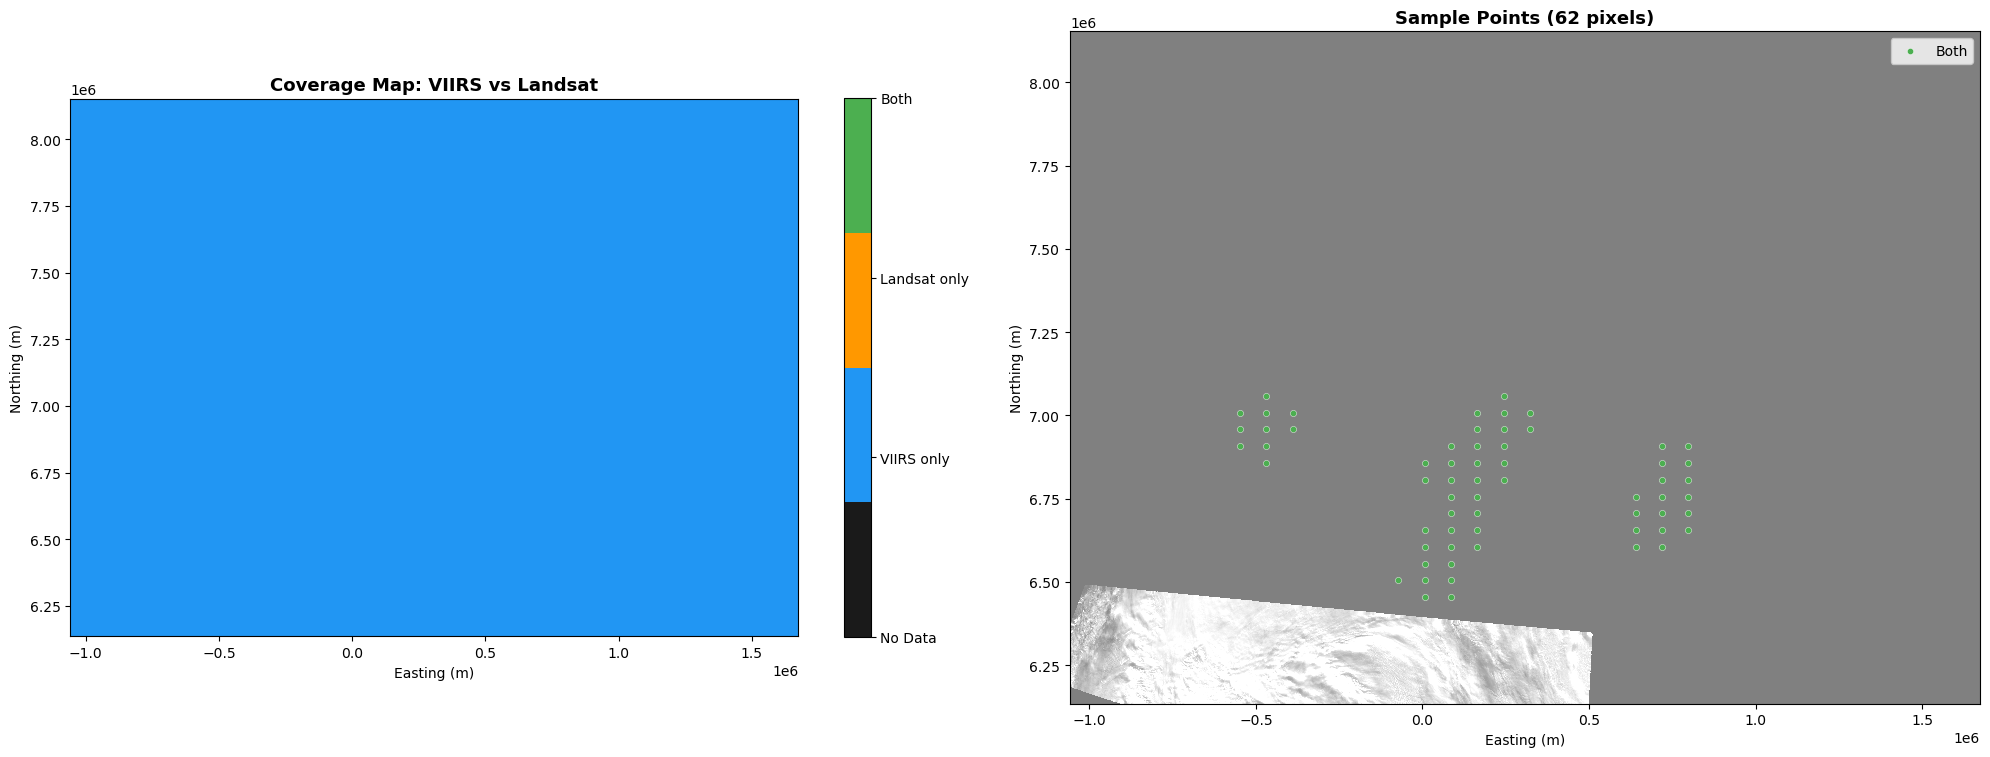

Coverage pixel counts (on VIIRS grid, sampled every 3rd col):
  VIIRS only     : 39,202,488
  Landsat only   :          0
  Both           :          0
  No data        :          0


In [37]:
# CELL 11b - OVERLAP MAP: Landsat over VIIRS with coverage distinction
# Colour-coded map showing where VIIRS-only, Landsat-only, and both overlap.

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Panel 1: Coverage mask on VIIRS grid ----------------------------------
# Build a mask: 0=no data, 1=VIIRS only, 2=Landsat only, 3=Both
coverage = np.zeros((vh, vw), dtype=np.uint8)

# Mark VIIRS valid pixels
vk_check = "I1" if "I1" in viirs_375 else next(k for k in viirs_375 if k.startswith("I"))
viirs_valid = np.isfinite(viirs_375[vk_check])
coverage[viirs_valid] = 1

# Mark Landsat valid pixels (mapped onto VIIRS grid)
landsat_check = mosaic_ds[next(iter(mosaic_ds))]
for vr_i in range(vh):
    for vc_i in range(0, vw, 3):  # sample every 3rd col for speed
        xu = viirs_tf.c + vc_i * viirs_tf.a
        yu = viirs_tf.f + vr_i * viirs_tf.e
        lc_i = int((xu - landsat_tf.c) / landsat_tf.a)
        lr_i = int((yu - landsat_tf.f) / landsat_tf.e)
        if 0 <= lr_i < landsat_check.shape[0] and 0 <= lc_i < landsat_check.shape[1]:
            if np.isfinite(landsat_check[lr_i // ds_factor, lc_i // ds_factor] if ds_factor > 1
                           else landsat_check[lr_i, lc_i]):
                if coverage[vr_i, vc_i] == 1:
                    coverage[vr_i, vc_i] = 3  # both
                else:
                    coverage[vr_i, vc_i] = 2  # landsat only

from matplotlib.colors import ListedColormap
cmap_cov = ListedColormap(["#1a1a1a", "#2196F3", "#FF9800", "#4CAF50"])  # nodata, VIIRS, Landsat, Both
im = axes[0].imshow(coverage, extent=v_ext, cmap=cmap_cov, vmin=0, vmax=3, interpolation="nearest")
cbar = plt.colorbar(im, ax=axes[0], ticks=[0, 1, 2, 3], shrink=0.7)
cbar.ax.set_yticklabels(["No Data", "VIIRS only", "Landsat only", "Both"])
axes[0].set_title("Coverage Map: VIIRS vs Landsat", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Easting (m)")
axes[0].set_ylabel("Northing (m)")

# --- Panel 2: Sample points coloured by overlap status ---------------------
if len(extract_df) > 0:
    both_df = extract_df[extract_df["Has_Both"]]
    viirs_only_df = extract_df[extract_df["Has_VIIRS"] & ~extract_df["Has_Landsat"]]
    landsat_only_df = extract_df[extract_df["Has_Landsat"] & ~extract_df["Has_VIIRS"]]

    # Background: VIIRS I1 grayscale
    d_bg = viirs_375[vk_check]
    vv = d_bg[np.isfinite(d_bg)]
    lo, hi = (np.percentile(vv, [2, 98]) if len(vv) else (0, 1))
    axes[1].imshow(d_bg, extent=v_ext, cmap="gray", vmin=lo, vmax=hi, interpolation="nearest", alpha=0.5)

    # Convert lat/lon back to UTM for plotting
    from_ll = Transformer.from_crs("EPSG:4326", utm_crs, always_xy=True)

    for df_sub, color, label in [
        (viirs_only_df, "#2196F3", "VIIRS only"),
        (landsat_only_df, "#FF9800", "Landsat only"),
        (both_df, "#4CAF50", "Both"),
    ]:
        if len(df_sub) > 0:
            xs, ys = from_ll.transform(df_sub["Lon"].values, df_sub["Lat"].values)
            axes[1].scatter(xs, ys, c=color, s=20, label=label, edgecolors="white", linewidths=0.3)

    axes[1].legend(loc="upper right", fontsize=10)
    axes[1].set_title(f"Sample Points ({len(extract_df)} pixels)", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Easting (m)")
    axes[1].set_ylabel("Northing (m)")

plt.tight_layout()
plt.show()

n_cov = {
    "VIIRS only": int((coverage == 1).sum()),
    "Landsat only": int((coverage == 2).sum()),
    "Both": int((coverage == 3).sum()),
    "No data": int((coverage == 0).sum()),
}
print("Coverage pixel counts (on VIIRS grid, sampled every 3rd col):")
for k, v in n_cov.items():
    print(f"  {k:15s}: {v:>10,}")

In [38]:
# CELL 12 - PER-CLASS TRAINING TABLES (structure for manual labelling)
# The 4 tables below have the same columns as the extraction table.
# After visually inspecting the Landsat RGB overlay, assign each pixel row
# to the appropriate class table.

class_columns = [
    "VIIRS_Acquisition_Date",
    "Pixel_Row", "Pixel_Col",
    "Solar_Zenith_Angle", "Solar_Azimuth_Angle",
    "Satellite_Zenith_Angle", "Satellite_Azimuth_Angle",
    "Band1", "Band2", "Band3", "Band4", "Band5",
    "Vegetation_Type", "Proxy_NDVI",
]

classes = {
    1: "Ice-free river and snow-free land",
    2: "Ice-free river and snow-covered land",
    3: "Ice-covered river and snow-free land",
    4: "Ice-covered river and snow-covered land",
}

for cls_id, cls_desc in classes.items():
    print(f"\n{'='*80}")
    print(f"CLASS {cls_id}: {cls_desc}")
    print(f"{'='*80}")
    df = pd.DataFrame(columns=class_columns)
    display(df)

print("\nFill these tables by copying rows from the extraction table above,")
print("classifying each pixel based on Landsat RGB visual inspection.")


CLASS 1: Ice-free river and snow-free land


,VIIRS_Acquisition_Date,Pixel_Row,Pixel_Col,Solar_Zenith_Angle,Solar_Azimuth_Angle,Satellite_Zenith_Angle,Satellite_Azimuth_Angle,Band1,Band2,Band3,Band4,Band5,Vegetation_Type,Proxy_NDVI



CLASS 2: Ice-free river and snow-covered land


,VIIRS_Acquisition_Date,Pixel_Row,Pixel_Col,Solar_Zenith_Angle,Solar_Azimuth_Angle,Satellite_Zenith_Angle,Satellite_Azimuth_Angle,Band1,Band2,Band3,Band4,Band5,Vegetation_Type,Proxy_NDVI



CLASS 3: Ice-covered river and snow-free land


,VIIRS_Acquisition_Date,Pixel_Row,Pixel_Col,Solar_Zenith_Angle,Solar_Azimuth_Angle,Satellite_Zenith_Angle,Satellite_Azimuth_Angle,Band1,Band2,Band3,Band4,Band5,Vegetation_Type,Proxy_NDVI



CLASS 4: Ice-covered river and snow-covered land


,VIIRS_Acquisition_Date,Pixel_Row,Pixel_Col,Solar_Zenith_Angle,Solar_Azimuth_Angle,Satellite_Zenith_Angle,Satellite_Azimuth_Angle,Band1,Band2,Band3,Band4,Band5,Vegetation_Type,Proxy_NDVI



Fill these tables by copying rows from the extraction table above,
classifying each pixel based on Landsat RGB visual inspection.
